# PLoRA Step 4 -- Rank Budgeting by Channel Salience

**Polyglotic LoRA (PLoRA)** -- Channel-Aware, Language-Routed Low-Rank Adaptation  
**Prerequisites**: Steps 1 & 2 (channel curves αλ(ℓ), deviation maps d̃λ(ℓ)), Step 3 (support sets Sλ)

---

## What this notebook implements

Given the per-language channel deviation maps d̃λ(ℓ) from Step 2 and the layer support sets Sλ from Step 3, this notebook:

| Sub-step | PLoRA §  | Description |
|---|---|---|
| **4.1** | §1.5.1 | Model architecture inventory & LoRA parameter accounting |
| **4.2** | §1.5.2 | Budgeted rank allocation: `rλ,ℓ = clip(rmin, rmax, ⌊Rλ · wλ,ℓ / Σwλ,j⌋)` |
| **4.3** | §1.4.3 | Selection stability (margin condition) cross-check |
| **4.4** | §1.5.2 | Optional fairness — inverse-proportional budgets across languages |
| **4.5** | §1.8   | Required figures: rank map rλ,ℓ, budget compliance, rank–salience scatter |
| **4.6** | §1.5.2 | Soft-mixture routing extension: ∆Wℓ(x) = Σλ p(λ|x) ∆W(λ)ℓ |
| **4.7** | —      | Persist rank allocation for Step 5 (training) |

## Key formula
```
wλ,ℓ  = (d̃λ(ℓ))^p                                     # channel salience weight
rλ,ℓ  = clip(rmin, rmax, ⌊Rλ · wλ,ℓ / Σj∈Sλ wλ,j⌋)   # rank allocation
#params = Σℓ∈Sλ rλ,ℓ · Σi(din_i + dout_i)             # parameter accounting
```

## Model
- `Qwen/Qwen3-4B-Instruct-2507` · 12 languages · 36 layers

## Imports & Dependencies

In [1]:
!pip install -q transformers pandas numpy matplotlib seaborn scipy

In [2]:
import json
import os
import warnings
from pathlib import Path
from itertools import product

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import LogNorm, Normalize
from matplotlib.patches import Patch, FancyBboxPatch
from matplotlib.lines import Line2D
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
import seaborn as sns
from scipy import stats

warnings.filterwarnings('ignore')
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.family': 'DejaVu Sans',
})

print('✓ Imports successful')

✓ Imports successful


## §4.0 — Load Outputs from Steps 1, 2 & 3

Step 4 is a **pure computation step** — no model inference needed.  
We load the CSV produced by Steps 1 & 2 and the support-set JSON from Step 3.

If `plora_step3_support_sets.json` is absent (Step 3 still in progress), we compute support sets here using the same Top-K logic specified in PLoRA §1.4.

In [3]:
# ─── Language catalogue (12 languages, same as Steps 1&2) ───────────────────
LANGUAGES = {
    'hin_Deva': 'Hindi',
    'fra_Latn': 'French',
    'cmn_Hans': 'Chinese',
    'urd_Arab': 'Urdu',
    'eng_Latn': 'English',
    'awa_Deva': 'Awadhi',
    'ben_Beng': 'Bengali',
    'mar_Deva': 'Marathi',
    'nld_Latn': 'Dutch',
    'pol_Latn': 'Polish',
    'snd_Arab': 'Sindhi',
    'azb_Arab': 'South Azerbaijani',
}

LANGUAGE_COLORS = {
    'eng_Latn': '#2563EB', 'fra_Latn': '#E11D48',
    'nld_Latn': '#F59E0B', 'pol_Latn': '#06B6D4',
    'hin_Deva': '#DC2626', 'awa_Deva': '#7C3AED',
    'mar_Deva': '#F97316', 'urd_Arab': '#10B981',
    'snd_Arab': '#EC4899', 'azb_Arab': '#84CC16',
    'cmn_Hans': '#8B5CF6', 'ben_Beng': '#14B8A6',
}

MODEL_ID = 'Qwen/Qwen3-4B-Instruct-2507'

# ─── Estimated dataset sizes (parallel corpora, OPUS-based) ─────────────────
# Used for inverse-proportional budget fairness (Step 4.4).
# Values are approximate sentence counts for each language on FLORES+/OPUS.
DATASET_SIZES = {
    'eng_Latn': 101_000,   # English   — very high resource
    'fra_Latn': 101_000,   # French    — very high resource
    'cmn_Hans': 101_000,   # Chinese   — very high resource
    'nld_Latn':  90_000,   # Dutch     — high resource
    'pol_Latn':  85_000,   # Polish    — high resource
    'hin_Deva':  75_000,   # Hindi     — high resource
    'ben_Beng':  60_000,   # Bengali   — medium resource
    'mar_Deva':  48_000,   # Marathi   — medium resource
    'urd_Arab':  44_000,   # Urdu      — medium resource
    'azb_Arab':  18_000,   # S. Azerbaijani — low resource
    'snd_Arab':  12_000,   # Sindhi    — low resource
    'awa_Deva':   5_500,   # Awadhi    — very low resource
}

print(f'Languages : {len(LANGUAGES)}')
print(f'Model     : {MODEL_ID}')

Languages : 12
Model     : Qwen/Qwen3-4B-Instruct-2507


In [4]:
# ─── Load Step 1&2 results ───────────────────────────────────────────────────
CSV_PATH = '/content/spinal_plora_qwen3_4b_results_12lang.csv'

if not Path(CSV_PATH).exists():
    raise FileNotFoundError(
        f'{CSV_PATH} not found.\n'
        'Please run Steps 1 & 2 (plora-s1-and-s2.ipynb) first '
        'and ensure the CSV was saved to the working directory.'
    )

df_steps12 = pd.read_csv(CSV_PATH)
n_layers   = len(df_steps12)   # number of transformer layers
lang_codes = [lc for lc in LANGUAGES if lc in df_steps12.columns or
              f"{LANGUAGES[lc]}_alpha_mean" in df_steps12.columns]

# Reconstruct per-language arrays
alpha_mean = {}   # ᾱλ(ℓ)
alpha_std  = {}   # sdλ(ℓ)
d_tilde    = {}   # d̃λ(ℓ)

for lc, name in LANGUAGES.items():
    col_mean = f'{name}_alpha_mean'
    col_std  = f'{name}_alpha_std'
    col_dtld = f'{name}_d_tilde'
    if all(c in df_steps12.columns for c in [col_mean, col_std, col_dtld]):
        alpha_mean[lc] = df_steps12[col_mean].tolist()
        alpha_std[lc]  = df_steps12[col_std].tolist()
        d_tilde[lc]    = df_steps12[col_dtld].tolist()

mu    = df_steps12['mu'].values     # cross-language mean α per layer
sigma = df_steps12['sigma'].values  # cross-language dispersion per layer
lang_codes = list(d_tilde.keys())

print(f'✓ Loaded Step 1&2 data  →  {n_layers} layers, {len(lang_codes)} languages')
print(f'  Languages: {[LANGUAGES[lc] for lc in lang_codes]}')
print(f'  Columns  : {list(df_steps12.columns[:6])} ...')

✓ Loaded Step 1&2 data  →  36 layers, 12 languages
  Languages: ['Hindi', 'French', 'Chinese', 'Urdu', 'English', 'Awadhi', 'Bengali', 'Marathi', 'Dutch', 'Polish', 'Sindhi', 'South Azerbaijani']
  Columns  : ['layer', 'Hindi_alpha_mean', 'Hindi_alpha_std', 'Hindi_d_tilde', 'French_alpha_mean', 'French_alpha_std'] ...


### Load Support Sets from Step 3

Step 3 produces `plora_step3_support_sets.json` with the schema:
```json
{
  "K_alpha": 10,
  "terminal_window": 3,
  "support_sets": {
    "eng_Latn": [2, 7, 14, 19, 23, 33, 34, 35, ...],
    ...
  }
}
```
If the file is absent, we compute support sets here using the identical Top-K logic from **PLoRA §1.4**, so this notebook is always runnable as a standalone unit.

In [11]:
# ─── Step 3 interface parameters ─────────────────────────────────────────────
K_ALPHA          = 10    # §1.4.1 — number of Top-K channel layers per language
TERMINAL_WINDOW  =  3    # §1.4.2 — always include last w layers in every Sλ

STEP3_JSON = '/content/plora_step3_support_sets.json'

def compute_support_sets_fallback(d_tilde, n_layers, k_alpha, terminal_window):
    """
    PLoRA §1.4 fallback — computes Sλ when Step 3 JSON is unavailable.

    Sλ = Top-K(d̃λ(ℓ)) ∪ Sterm
    Sterm = {L-w, L-w+1, …, L-1}
    """
    Sterm = set(range(n_layers - terminal_window, n_layers))
    support_sets = {}
    for lc, scores in d_tilde.items():
        ranked = sorted(range(n_layers), key=lambda i: scores[i], reverse=True)
        S_alpha = set(ranked[:k_alpha])
        support_sets[lc] = sorted(S_alpha | Sterm)
    return support_sets

# ─── Try to load from Step 3; fall back to computing locally ─────────────────
step3_source = None
if Path(STEP3_JSON).exists():
    with open(STEP3_JSON) as f:
        step3_data = json.load(f)
    support_sets_raw = step3_data.get('support_sets', {})
    # Normalise to sets of int
    support_sets = {lc: sorted(set(int(x) for x in layers))
                    for lc, layers in support_sets_raw.items()
                    if lc in lang_codes}
    K_ALPHA         = step3_data.get('K_alpha', K_ALPHA)
    TERMINAL_WINDOW = step3_data.get('terminal_window', TERMINAL_WINDOW)
    step3_source = 'file'
    print(f'✓ Loaded support sets from {STEP3_JSON}  (K_alpha={K_ALPHA}, Sterm_w={TERMINAL_WINDOW})')
else:
    support_sets = compute_support_sets_fallback(d_tilde, n_layers, K_ALPHA, TERMINAL_WINDOW)
    step3_source = 'computed_fallback'
    print(f'⚠ {STEP3_JSON} not found — computing support sets internally (fallback).')
    print(f'  Using K_alpha={K_ALPHA}, terminal_window={TERMINAL_WINDOW}')

# Ensure every language has a support set
for lc in lang_codes:
    if lc not in support_sets:
        support_sets[lc] = compute_support_sets_fallback(
            {lc: d_tilde[lc]}, n_layers, K_ALPHA, TERMINAL_WINDOW
        )[lc]

print(f'\nSupport set sizes (|Sλ| per language):')
for lc in lang_codes:
    print(f'  {LANGUAGES[lc]:<22}: |Sλ|={len(support_sets[lc])}  '
          f'layers={support_sets[lc]}')

✓ Loaded support sets from /content/plora_step3_support_sets.json  (K_alpha=10, Sterm_w=3)

Support set sizes (|Sλ| per language):
  Hindi                 : |Sλ|=11  layers=[0, 1, 2, 3, 4, 5, 6, 7, 33, 34, 35]
  French                : |Sλ|=7  layers=[3, 4, 6, 10, 33, 34, 35]
  Chinese               : |Sλ|=5  layers=[0, 1, 33, 34, 35]
  Urdu                  : |Sλ|=4  layers=[32, 33, 34, 35]
  English               : |Sλ|=5  layers=[0, 22, 33, 34, 35]
  Awadhi                : |Sλ|=7  layers=[0, 1, 2, 5, 33, 34, 35]
  Bengali               : |Sλ|=7  layers=[2, 3, 4, 6, 33, 34, 35]
  Marathi               : |Sλ|=7  layers=[0, 2, 3, 8, 33, 34, 35]
  Dutch                 : |Sλ|=7  layers=[29, 30, 31, 32, 33, 34, 35]
  Polish                : |Sλ|=7  layers=[5, 6, 8, 9, 33, 34, 35]
  Sindhi                : |Sλ|=4  layers=[32, 33, 34, 35]
  South Azerbaijani     : |Sλ|=5  layers=[19, 32, 33, 34, 35]


## §4.1 — Model Architecture & LoRA Parameter Accounting

**PLoRA §1.5.1:** for each LoRA module on matrix W ∈ ℝ^{dout × din} with rank r:
```
#params(ΔW) = r(din + dout)
```
Layers adapting multiple target matrices (Wq, Wk, Wv, Wo, Wgate, Wup, Wdown) sum costs across all targets.

In [12]:
# ─── Read model architecture dynamically ─────────────────────────────────────
def load_model_arch(model_id):
    """
    Reads architecture dimensions from HuggingFace config.
    Falls back to hardcoded Qwen3-4B defaults if unavailable.
    """
    try:
        from transformers import AutoConfig
        cfg = AutoConfig.from_pretrained(model_id, trust_remote_code=True)
        # Qwen3 may expose head_dim directly
        if hasattr(cfg, 'head_dim') and cfg.head_dim is not None:
            head_dim = cfg.head_dim
        else:
            head_dim = cfg.hidden_size // cfg.num_attention_heads
        arch = {
            'hidden_size'          : cfg.hidden_size,
            'num_attention_heads'  : cfg.num_attention_heads,
            'num_key_value_heads'  : getattr(cfg, 'num_key_value_heads',
                                             cfg.num_attention_heads),
            'head_dim'             : head_dim,
            'intermediate_size'    : cfg.intermediate_size,
            'num_hidden_layers'    : cfg.num_hidden_layers,
            'vocab_size'           : cfg.vocab_size,
        }
        print(f'✓ Architecture loaded from HuggingFace config')
        return arch
    except Exception as e:
        print(f'⚠ Could not fetch config ({e}) — using Qwen3-4B defaults')
        return None

QWEN3_4B_DEFAULTS = {
    'hidden_size'        : 2560,
    'num_attention_heads': 32,
    'num_key_value_heads': 8,
    'head_dim'           : 128,      # 32 heads × 128 → q_dim = 4096
    'intermediate_size'  : 8960,     # SwiGLU FFN width
    'num_hidden_layers'  : 36,
    'vocab_size'         : 151936,
}

MODEL_ARCH = load_model_arch(MODEL_ID) or QWEN3_4B_DEFAULTS

# Derived dimensions
d        = MODEL_ARCH['hidden_size']
n_heads  = MODEL_ARCH['num_attention_heads']
n_kv     = MODEL_ARCH['num_key_value_heads']
h_dim    = MODEL_ARCH['head_dim']
ffn      = MODEL_ARCH['intermediate_size']
n_layers_arch = MODEL_ARCH['num_hidden_layers']

# Confirm n_layers matches the CSV
assert n_layers == n_layers_arch, (
    f'n_layers mismatch: CSV={n_layers}, arch={n_layers_arch}. '
    f'Check model config or CSV file.'
)

print(f'\nModel Architecture Summary')
print(f'  hidden_size        : {d}')
print(f'  num_attention_heads: {n_heads}  (Q dim = {n_heads * h_dim})')
print(f'  num_kv_heads       : {n_kv}   (K/V dim = {n_kv * h_dim})')
print(f'  head_dim           : {h_dim}')
print(f'  intermediate_size  : {ffn}')
print(f'  num_hidden_layers  : {n_layers}')

config.json:   0%|          | 0.00/727 [00:00<?, ?B/s]

✓ Architecture loaded from HuggingFace config

Model Architecture Summary
  hidden_size        : 2560
  num_attention_heads: 32  (Q dim = 4096)
  num_kv_heads       : 8   (K/V dim = 1024)
  head_dim           : 128
  intermediate_size  : 9728
  num_hidden_layers  : 36


In [13]:
# ─── LoRA target matrix catalogue ────────────────────────────────────────────
# Each entry: target_name → (d_in, d_out)
# LoRA param cost = rank × (d_in + d_out)

q_dim  = n_heads * h_dim   # Q output dimension
kv_dim = n_kv   * h_dim   # K/V output dimension

LORA_TARGETS_ATTN = {           # Attention-only target set
    'q_proj' : (d,      q_dim),
    'k_proj' : (d,      kv_dim),
    'v_proj' : (d,      kv_dim),
    'o_proj' : (q_dim,  d),
}

LORA_TARGETS_MLP = {            # MLP-only target set (SwiGLU)
    'gate_proj': (d,   ffn),
    'up_proj'  : (d,   ffn),
    'down_proj': (ffn, d),
}

LORA_TARGETS_FULL = {           # Full target set (default for PLoRA)
    **LORA_TARGETS_ATTN,
    **LORA_TARGETS_MLP,
}

TARGET_SETS = {
    'attention_only': LORA_TARGETS_ATTN,
    'mlp_only'      : LORA_TARGETS_MLP,
    'full'          : LORA_TARGETS_FULL,   # ← used as default
}

ACTIVE_TARGET_SET = 'full'    # change to 'attention_only' or 'mlp_only' if desired
LORA_TARGETS = TARGET_SETS[ACTIVE_TARGET_SET]

# ─── Parameter counting functions ────────────────────────────────────────────
def lora_param_cost_per_layer(rank, targets=LORA_TARGETS):
    """
    PLoRA §1.5.1: #params(ΔW) = r(din + dout) summed over all target matrices.
    This is the total LoRA parameter cost for ONE layer at a given rank.
    """
    return sum(rank * (din + dout) for din, dout in targets.values())

def lora_param_cost_language(rank_map, targets=LORA_TARGETS):
    """
    Total LoRA parameters for one language given its layer→rank map.
    rank_map: dict {layer_idx: rank}
    """
    return sum(lora_param_cost_per_layer(r, targets) for r in rank_map.values())

# ─── Parameter cost table ────────────────────────────────────────────────────
print('LoRA Parameter Cost per Layer (in millions) by Rank:')
print(f'{"Rank":>6}  {"Attention":>14}  {"MLP":>14}  {"Full":>14}')
print('-' * 56)
for r in [4, 8, 16, 32, 64, 128]:
    c_attn = lora_param_cost_per_layer(r, LORA_TARGETS_ATTN)  / 1e6
    c_mlp  = lora_param_cost_per_layer(r, LORA_TARGETS_MLP)   / 1e6
    c_full = lora_param_cost_per_layer(r, LORA_TARGETS_FULL)  / 1e6
    print(f'{r:>6}  {c_attn:>13.3f}M  {c_mlp:>13.3f}M  {c_full:>13.3f}M')

LoRA Parameter Cost per Layer (in millions) by Rank:
  Rank       Attention             MLP            Full
--------------------------------------------------------
     4          0.082M          0.147M          0.229M
     8          0.164M          0.295M          0.459M
    16          0.328M          0.590M          0.918M
    32          0.655M          1.180M          1.835M
    64          1.311M          2.359M          3.670M
   128          2.621M          4.719M          7.340M


## §4.2 — Rank Budget Hyperparameters

| Parameter | Symbol | Meaning |
|---|---|---|
| `R_LAMBDA`  | Rλ   | Per-language rank budget (total rank-mass across Sλ) |
| `R_MIN`     | rmin | Minimum rank per layer (prevents zero adaptation) |
| `R_MAX`     | rmax | Maximum rank per layer (bounds memory cost) |
| `P_EXP`     | p    | Salience weighting exponent — larger p = sharper concentration |

> **Intuition**: with `|Sλ|` ≈ 13 and `R_LAMBDA=256`, the *average* rank ≈ 20.  
> High-salience layers receive up to `R_MAX=64`; low-salience layers receive ≥ `R_MIN=4`.

In [14]:
# ─── Rank budget configuration ───────────────────────────────────────────────
R_LAMBDA  = 256   # per-language rank budget Rλ  (rank-mass units)
R_MIN     =   4   # rmin — minimum rank per layer
R_MAX     =  64   # rmax — maximum rank per layer
P_EXP     =   2   # p ≥ 1 — salience exponent; p=1 → linear, p=2 → quadratic

# Fairness configuration (§4.4)
GAMMA          = 0.5   # inverse-proportional exponent: Rλ ∝ |Dλ|^{-γ}
R_FAIR_MIN     = 128   # minimum budget for any language under fairness
R_FAIR_MAX     = 512   # maximum budget for any language under fairness
R_FAIR_MEDIAN  = 256   # target median budget under fairness (= R_LAMBDA)

print('Rank Budget Configuration')
print(f'  R_LAMBDA (Rλ)  = {R_LAMBDA}  (rank-mass per language)')
print(f'  R_MIN   (rmin) = {R_MIN}')
print(f'  R_MAX   (rmax) = {R_MAX}')
print(f'  P_EXP   (p)    = {P_EXP}  (salience exponent)')
print(f'  GAMMA   (γ)    = {GAMMA}  (fairness exponent)')

# Sanity checks
assert R_MIN >= 1,       'R_MIN must be ≥ 1'
assert R_MAX >= R_MIN,   'R_MAX must be ≥ R_MIN'
assert P_EXP >= 1,       'P_EXP must be ≥ 1'
assert 0 <= GAMMA <= 1,  'GAMMA must be in [0,1]'
print('\n✓ Configuration validated')

Rank Budget Configuration
  R_LAMBDA (Rλ)  = 256  (rank-mass per language)
  R_MIN   (rmin) = 4
  R_MAX   (rmax) = 64
  P_EXP   (p)    = 2  (salience exponent)
  GAMMA   (γ)    = 0.5  (fairness exponent)

✓ Configuration validated


## §4.2 — Core Rank Allocation Algorithm

**PLoRA §1.5.2** specifies:

```
For ℓ ∈ Sλ:
  wλ,ℓ  = (d̃λ(ℓ))^p
  Zλ    = Σ_{j ∈ Sλ} wλ,j
  rλ,ℓ  = clip(rmin, rmax, ⌊Rλ · wλ,ℓ / Zλ⌋)
```

This concentrates rank capacity at layers where language λ diverges most from the shared multilingual backbone, subject to per-layer bounds.

In [15]:
def allocate_ranks(
    d_tilde_lang : list,
    support_set  : list,
    R_lambda     : float,
    r_min        : int,
    r_max        : int,
    p            : float = 2.0,
) -> dict:
    """
    PLoRA §1.5.2 — Budgeted rank allocation.

    Parameters
    ----------
    d_tilde_lang : list[float] of length n_layers
        Normalized channel deviation d̃λ(ℓ) from Step 2.
    support_set  : list[int]
        Sorted list of layer indices Sλ from Step 3 (or fallback).
    R_lambda     : float
        Per-language rank budget (total rank-mass units).
    r_min, r_max : int
        Rank bounds for clipping.
    p            : float
        Salience exponent (p ≥ 1).  Larger p concentrates rank on top layers.

    Returns
    -------
    dict {layer_idx: rank}
        Rank allocated to each layer in the support set.

    Notes
    -----
    - Layers outside Sλ receive rank 0 (no adapter).
    - A floor of 1e-8 is applied to d̃λ(ℓ) before exponentiation to prevent
      zero weights when deviation scores are exactly 0.
    - Total allocated rank-mass = Σ rλ,ℓ may differ slightly from R_lambda
      due to integer rounding and clipping; this is expected and validated below.
    """
    if len(support_set) == 0:
        return {}

    # ── Step 1: compute channel salience weights wλ,ℓ = (d̃λ(ℓ))^p ───────
    weights = {}
    for ell in support_set:
        d_val = float(d_tilde_lang[ell])
        weights[ell] = max(d_val, 1e-8) ** p   # floor prevents zero weight

    Z = sum(weights.values())   # normalisation constant

    # ── Step 2: proportional allocation with clipping ─────────────────────
    ranks = {}
    for ell in support_set:
        raw_rank      = R_lambda * weights[ell] / Z
        ranks[ell]    = int(np.clip(round(raw_rank), r_min, r_max))

    return ranks


def rank_map_matrix(all_ranks, lang_codes, n_layers):
    """
    Build a dense [n_languages × n_layers] rank matrix for visualisation.
    Zero entries = layer not in Sλ (no adapter for that language at that layer).
    """
    mat = np.zeros((len(lang_codes), n_layers), dtype=int)
    for i, lc in enumerate(lang_codes):
        for ell, r in all_ranks[lc].items():
            mat[i, ell] = r
    return mat


print('✓ allocate_ranks() and rank_map_matrix() defined')

✓ allocate_ranks() and rank_map_matrix() defined


In [16]:
# ─── Apply allocation — equal budgets (baseline strategy) ────────────────────
# All languages receive the same rank budget Rλ = R_LAMBDA.
# This is the canonical PLoRA allocation; fairness variants follow.

all_ranks_equal = {}   # {lang_code: {layer_idx: rank}}

for lc in lang_codes:
    all_ranks_equal[lc] = allocate_ranks(
        d_tilde_lang = d_tilde[lc],
        support_set  = support_sets[lc],
        R_lambda     = R_LAMBDA,
        r_min        = R_MIN,
        r_max        = R_MAX,
        p            = P_EXP,
    )

# Build dense rank matrix
rank_matrix_equal = rank_map_matrix(all_ranks_equal, lang_codes, n_layers)

# ─── Quick allocation summary ─────────────────────────────────────────────────
print('Rank Allocation Summary (equal budgets, Rλ={R_LAMBDA})')
print(f'{"Language":<24} {"Layers":>6} {"MinR":>5} {"MaxR":>5} {"MeanR":>7} '
      f'{"Σrank":>7} {"Params (M)":>12}')
print('-' * 78)
total_params_all = 0
for lc in lang_codes:
    rm   = all_ranks_equal[lc]
    if not rm:
        continue
    rs   = list(rm.values())
    tot  = lora_param_cost_language(rm)
    total_params_all += tot
    print(f'{LANGUAGES[lc]:<24} {len(rm):>6} {min(rs):>5} {max(rs):>5} '
          f'{np.mean(rs):>7.1f} {sum(rs):>7} {tot/1e6:>11.3f}M')
print('-' * 78)
print(f'{"Total (all languages)":<24} {"":>6} {"":>5} {"":>5} {"":>7} '
      f'{"":>7} {total_params_all/1e6:>11.3f}M')

Rank Allocation Summary (equal budgets, Rλ={R_LAMBDA})
Language                 Layers  MinR  MaxR   MeanR   Σrank   Params (M)
------------------------------------------------------------------------------
Hindi                        11     4    37    24.2     266      15.254M
French                        7     6    59    36.6     256      14.680M
Chinese                       5    40    64    50.4     252      14.451M
Urdu                          4    57    64    62.2     249      14.279M
English                       5    38    60    51.0     255      14.623M
Awadhi                        7     4    64    37.0     259      14.852M
Bengali                       7     4    63    37.3     261      14.967M
Marathi                       7     4    61    37.3     261      14.967M
Dutch                         7     7    64    36.4     255      14.623M
Polish                        7     4    64    35.9     251      14.393M
Sindhi                        4    47    64    59.2     237    

## §4.3 — Selection Stability: Margin Condition

**PLoRA §1.4.3:** the Top-K layer selection from Step 3 is stable if:
```
d̃λ(ℓ(K)) − d̃λ(ℓ(K+1))  >  2ε
```
where ε bounds the estimation noise from subsampling (approximated by the mean `sdλ(ℓ)`).

If the margin is narrow, we flag that language and recommend:
- Smoothing α̅λ(ℓ) across depth before recomputing d̃  
- Reducing K_alpha  
- Taking the union of selections across subsampling runs

In [17]:
def check_selection_margin(
    d_tilde_lang : list,
    sd_lang      : list,
    k_alpha      : int,
):
    """
    PLoRA §1.4.3 — Check stability of Top-K layer selection.

    Returns
    -------
    margin       : float  — gap between K-th and (K+1)-th deviation score
    noise_bound  : float  — 2 × mean subsampling std (the threshold)
    is_stable    : bool   — True if margin > noise_bound
    k_star       : int    — actual rank of the K-th chosen layer (1-based)
    """
    L     = len(d_tilde_lang)
    order = sorted(range(L), key=lambda i: d_tilde_lang[i], reverse=True)
    if k_alpha >= L:
        return 0.0, 0.0, True, k_alpha

    score_k   = d_tilde_lang[order[k_alpha - 1]]
    score_k1  = d_tilde_lang[order[k_alpha]]
    margin    = score_k - score_k1

    # Noise bound: 2 × mean subsampling std across all layers
    noise_bound = 2.0 * float(np.mean(sd_lang))

    return margin, noise_bound, margin > noise_bound, order[k_alpha - 1]


print(f'Selection Margin Analysis (K_alpha={K_ALPHA})')
print(f'{"Language":<24} {"Margin":>9} {"2×Noise":>9} {"Stable":>7} {"Action"}')
print('-' * 70)

unstable_langs = []
for lc in lang_codes:
    margin, noise_bound, stable, _ = check_selection_margin(
        d_tilde[lc], alpha_std[lc], K_ALPHA
    )
    status = '✓' if stable else '⚠'
    action = 'OK' if stable else 'Consider smoothing / smaller K'
    if not stable:
        unstable_langs.append(lc)
    print(f'{LANGUAGES[lc]:<24} {margin:>9.4f} {noise_bound:>9.4f} '
          f'{status:>7}  {action}')

if unstable_langs:
    print(f'\n⚠ Unstable languages: {[LANGUAGES[lc] for lc in unstable_langs]}')
    print('  → Their support sets may be sensitive to subsampling. '
          'Consider reducing K_alpha by 1–2 for these languages.')
else:
    print('\n✓ All language support sets are selection-stable.')

Selection Margin Analysis (K_alpha=10)
Language                    Margin   2×Noise  Stable Action
----------------------------------------------------------------------
Hindi                       0.0033    0.0263       ⚠  Consider smoothing / smaller K
French                      0.0079    0.0392       ⚠  Consider smoothing / smaller K
Chinese                     0.0256    0.0420       ⚠  Consider smoothing / smaller K
Urdu                        0.0059    0.0265       ⚠  Consider smoothing / smaller K
English                     0.0005    0.0388       ⚠  Consider smoothing / smaller K
Awadhi                      0.0045    0.0233       ⚠  Consider smoothing / smaller K
Bengali                     0.0179    0.0217       ⚠  Consider smoothing / smaller K
Marathi                     0.0155    0.0244       ⚠  Consider smoothing / smaller K
Dutch                       0.0008    0.0341       ⚠  Consider smoothing / smaller K
Polish                      0.0249    0.0306       ⚠  Consider sm

## §4.4 — Fairness: Inverse-Proportional Budgets

**PLoRA §1.5.2 (optional):** to avoid over-allocating to high-resource languages:
```
Rλ  ∝  |Dλ|^{−γ},   γ ∈ [0, 1]
```
Normalised so the *median* budget equals R_LAMBDA, then clipped to [R_FAIR_MIN, R_FAIR_MAX].

- `γ = 0` → uniform budgets (equal treatment)
- `γ = 0.5` → moderate minority boost  
- `γ = 1.0` → full inverse-proportional (strong minority boost)

In [18]:
def compute_fair_budgets(
    dataset_sizes : dict,
    lang_codes    : list,
    R_base        : float,
    gamma         : float,
    R_min         : float,
    R_max         : float,
) -> dict:
    """
    PLoRA §1.5.2 — Inverse-proportional per-language budgets.

    Rλ_raw = |Dλ|^{-γ}
    Rλ     = clip(R_min, R_max, Rλ_raw × (R_base / median(Rλ_raw)))
    """
    raw = {lc: dataset_sizes.get(lc, R_base) ** (-gamma)
           for lc in lang_codes}
    median_raw = float(np.median(list(raw.values())))
    scale      = R_base / (median_raw + 1e-12)
    budgets    = {
        lc: float(np.clip(v * scale, R_min, R_max))
        for lc, v in raw.items()
    }
    return budgets


# ── Compute fair budgets for several γ values ──────────────────────────────
gamma_sweep = [0.0, 0.25, 0.5, 0.75, 1.0]
fair_budgets_sweep = {}

for g in gamma_sweep:
    fair_budgets_sweep[g] = compute_fair_budgets(
        DATASET_SIZES, lang_codes,
        R_base=R_FAIR_MEDIAN,
        gamma=g,
        R_min=R_FAIR_MIN,
        R_max=R_FAIR_MAX,
    )

# Default fair budget uses GAMMA
fair_budgets = fair_budgets_sweep[GAMMA]

# ── Apply fair allocation ─────────────────────────────────────────────────
all_ranks_fair = {}
for lc in lang_codes:
    all_ranks_fair[lc] = allocate_ranks(
        d_tilde_lang = d_tilde[lc],
        support_set  = support_sets[lc],
        R_lambda     = fair_budgets[lc],
        r_min        = R_MIN,
        r_max        = R_MAX,
        p            = P_EXP,
    )

rank_matrix_fair = rank_map_matrix(all_ranks_fair, lang_codes, n_layers)

# ── Summary table ─────────────────────────────────────────────────────────
print(f'Fair Budget Allocation Summary (γ={GAMMA})')
print(f'{"Language":<24} {"Dataset":>9} {"Rλ (fair)":>10} '
      f'{"Rλ (equal)":>11} {"Boost":>7} {"Params (M)":>11}')
print('-' * 80)
for lc in lang_codes:
    ds   = DATASET_SIZES.get(lc, 0)
    rb   = fair_budgets[lc]
    boost= rb / R_LAMBDA
    tot  = lora_param_cost_language(all_ranks_fair[lc])
    print(f'{LANGUAGES[lc]:<24} {ds:>9,} {rb:>10.1f} '
          f'{R_LAMBDA:>11}  {boost:>6.2f}×  {tot/1e6:>10.3f}M')

Fair Budget Allocation Summary (γ=0.5)
Language                   Dataset  Rλ (fair)  Rλ (equal)   Boost  Params (M)
--------------------------------------------------------------------------------
Hindi                       75,000      241.7         256    0.94×      14.451M
French                     101,000      208.3         256    0.81×      11.985M
Chinese                    101,000      208.3         256    0.81×      11.928M
Urdu                        44,000      315.6         256    1.23×      14.680M
English                    101,000      208.3         256    0.81×      11.985M
Awadhi                       5,500      512.0         256    2.00×      15.884M
Bengali                     60,000      270.3         256    1.06×      15.655M
Marathi                     48,000      302.2         256    1.18×      16.171M
Dutch                       90,000      220.7         256    0.86×      12.616M
Polish                      85,000      227.1         256    0.89×      13.132M
Si

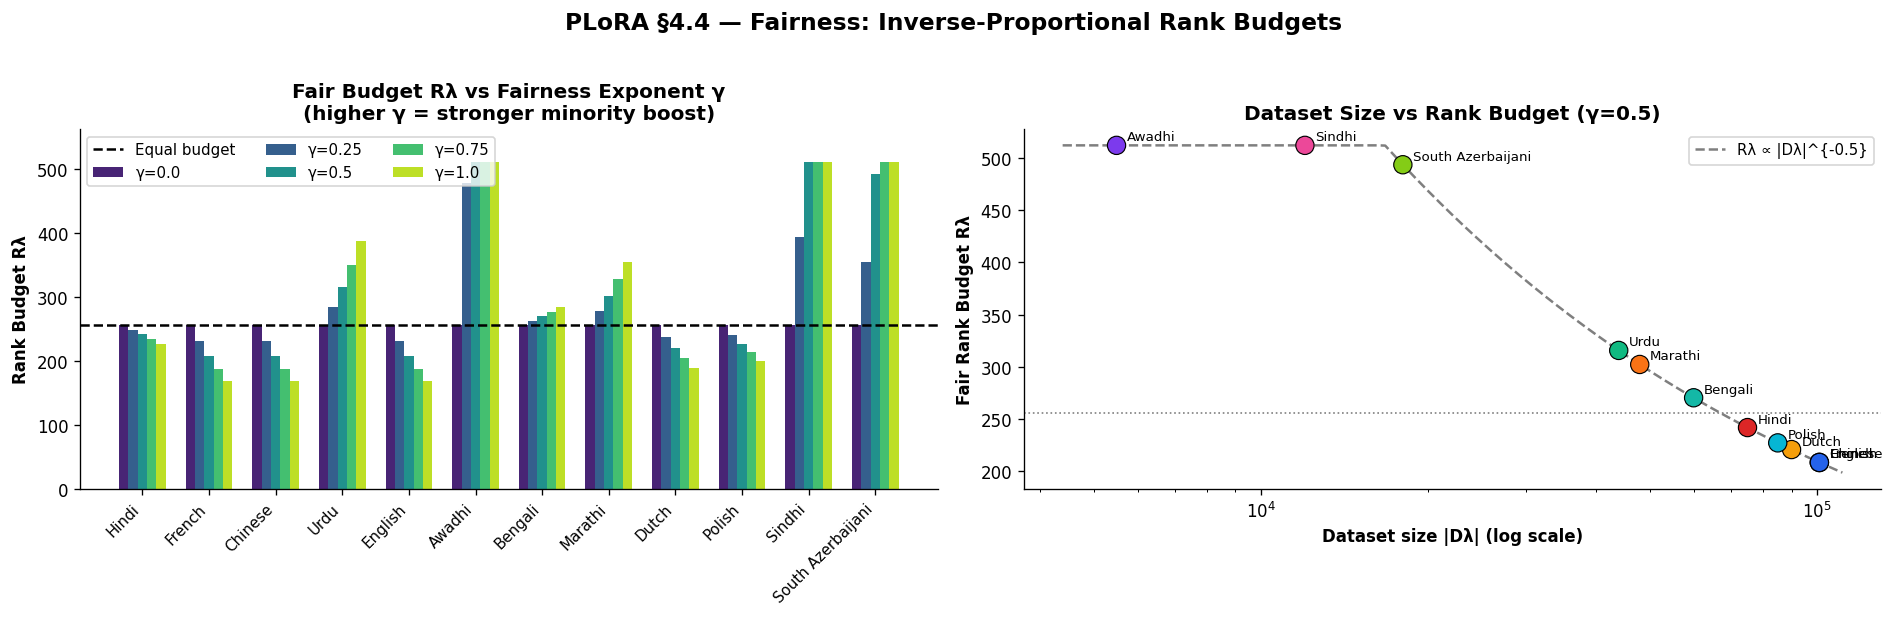

Saved: plora_step4_fairness_budgets.png


In [19]:
# ─── γ sweep: compare minority boost across fairness regimes ─────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Plot 1 — Rλ per language across γ values
ax = axes[0]
x  = np.arange(len(lang_codes))
width  = 0.14
colors = plt.cm.viridis(np.linspace(0.1, 0.9, len(gamma_sweep)))
for k, (g, color) in enumerate(zip(gamma_sweep, colors)):
    budgets_g = [fair_budgets_sweep[g][lc] for lc in lang_codes]
    ax.bar(x + k * width, budgets_g, width=width, label=f'γ={g}', color=color)
ax.axhline(R_LAMBDA, color='black', linestyle='--', linewidth=1.5, label='Equal budget')
ax.set_xticks(x + width * (len(gamma_sweep) - 1) / 2)
ax.set_xticklabels([LANGUAGES[lc] for lc in lang_codes], rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Rank Budget Rλ', fontweight='bold')
ax.set_title('Fair Budget Rλ vs Fairness Exponent γ\n(higher γ = stronger minority boost)',
             fontweight='bold')
ax.legend(fontsize=9, ncol=3)
ax.set_ylim(0, R_FAIR_MAX * 1.1)

# Plot 2 — Dataset size vs budget (γ=0.5 shown)
ax2 = axes[1]
ds_sizes  = [DATASET_SIZES.get(lc, 1) for lc in lang_codes]
budgets_g = [fair_budgets[lc] for lc in lang_codes]
clrs      = [LANGUAGE_COLORS.get(lc, '#888') for lc in lang_codes]
ax2.scatter(ds_sizes, budgets_g, c=clrs, s=120, zorder=3, edgecolors='black', linewidth=0.7)
for i, lc in enumerate(lang_codes):
    ax2.annotate(LANGUAGES[lc], (ds_sizes[i], budgets_g[i]),
                 textcoords='offset points', xytext=(6, 3), fontsize=8)
# Theoretical curve
xs  = np.linspace(min(ds_sizes) * 0.8, max(ds_sizes) * 1.1, 200)
raw = xs ** (-GAMMA)
ys  = raw / (np.median([DATASET_SIZES.get(lc, 1) ** (-GAMMA) for lc in lang_codes]) + 1e-12) * R_FAIR_MEDIAN
ys  = np.clip(ys, R_FAIR_MIN, R_FAIR_MAX)
ax2.plot(xs, ys, 'k--', linewidth=1.5, alpha=0.5, label=f'Rλ ∝ |Dλ|^{{-{GAMMA}}}')
ax2.set_xscale('log')
ax2.set_xlabel('Dataset size |Dλ| (log scale)', fontweight='bold')
ax2.set_ylabel('Fair Rank Budget Rλ', fontweight='bold')
ax2.set_title(f'Dataset Size vs Rank Budget (γ={GAMMA})', fontweight='bold')
ax2.legend(fontsize=9)
ax2.axhline(R_LAMBDA, color='gray', linestyle=':', linewidth=1)

plt.suptitle('PLoRA §4.4 — Fairness: Inverse-Proportional Rank Budgets',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('plora_step4_fairness_budgets.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: plora_step4_fairness_budgets.png')

## §4.5 — Budget Validation

We verify that:
1. All ranks lie in `[R_MIN, R_MAX]`  
2. Allocated rank-mass is within ±20% of Rλ (clipping + rounding tolerance)  
3. Parameter totals match expectations from the architecture inventory

In [20]:
def validate_allocation(
    all_ranks : dict,
    budgets   : dict,
    r_min     : int,
    r_max     : int,
    tolerance : float = 0.30,
) -> pd.DataFrame:
    """
    Validate rank allocation against stated budgets.

    Checks
    ------
    1. All ranks in [r_min, r_max]
    2. Σ rλ,ℓ within tolerance fraction of Rλ
    3. No empty support sets
    """
    rows = []
    for lc, rm in all_ranks.items():
        if not rm:
            rows.append({'lang': LANGUAGES[lc], 'status': '⚠ empty', 'msg': 'Empty support set'})
            continue

        rs        = list(rm.values())
        R_actual  = sum(rs)
        R_target  = budgets.get(lc, R_LAMBDA)
        rel_err   = abs(R_actual - R_target) / max(R_target, 1e-8)
        rank_ok   = all(r_min <= r <= r_max for r in rs)
        budget_ok = rel_err <= tolerance

        status = '✓' if (rank_ok and budget_ok) else '⚠'
        issues = []
        if not rank_ok:
            out = [r for r in rs if not (r_min <= r <= r_max)]
            issues.append(f'ranks out of [{r_min},{r_max}]: {out}')
        if not budget_ok:
            issues.append(f'rank-mass error {rel_err*100:.1f}% (> {tolerance*100:.0f}%)')

        rows.append({
            'Language'    : LANGUAGES[lc],
            'Rλ (target)' : f'{R_target:.0f}',
            'Σrλ,ℓ (actual)': R_actual,
            'Error'       : f'{rel_err*100:.1f}%',
            'Rank range'  : f'[{min(rs)}, {max(rs)}]',
            'Layers'      : len(rm),
            'Params (M)'  : f'{lora_param_cost_language(rm)/1e6:.3f}',
            'Status'      : status,
            'Issues'      : '; '.join(issues) or 'None',
        })
    return pd.DataFrame(rows)


# Validate equal-budget allocation
equal_budgets = {lc: R_LAMBDA for lc in lang_codes}
df_valid_equal = validate_allocation(all_ranks_equal, equal_budgets, R_MIN, R_MAX)

print('Validation — Equal Budgets (Rλ = R_LAMBDA for all λ)')
print(df_valid_equal.to_string(index=False))

n_pass = (df_valid_equal['Status'] == '✓').sum()
print(f'\n  {n_pass}/{len(df_valid_equal)} languages passed all checks.')

Validation — Equal Budgets (Rλ = R_LAMBDA for all λ)
         Language Rλ (target)  Σrλ,ℓ (actual) Error Rank range  Layers Params (M) Status Issues
            Hindi         256             266  3.9%    [4, 37]      11     15.254      ✓   None
           French         256             256  0.0%    [6, 59]       7     14.680      ✓   None
          Chinese         256             252  1.6%   [40, 64]       5     14.451      ✓   None
             Urdu         256             249  2.7%   [57, 64]       4     14.279      ✓   None
          English         256             255  0.4%   [38, 60]       5     14.623      ✓   None
           Awadhi         256             259  1.2%    [4, 64]       7     14.852      ✓   None
          Bengali         256             261  2.0%    [4, 63]       7     14.967      ✓   None
          Marathi         256             261  2.0%    [4, 61]       7     14.967      ✓   None
            Dutch         256             255  0.4%    [7, 64]       7     14.623  

In [21]:
# Validate fair allocation
df_valid_fair = validate_allocation(all_ranks_fair, fair_budgets, R_MIN, R_MAX)
print('Validation — Fair Budgets (γ={GAMMA})')
print(df_valid_fair.to_string(index=False))

n_pass_fair = (df_valid_fair['Status'] == '✓').sum()
print(f'\n  {n_pass_fair}/{len(df_valid_fair)} languages passed all checks.')

Validation — Fair Budgets (γ={GAMMA})
         Language Rλ (target)  Σrλ,ℓ (actual) Error Rank range  Layers Params (M) Status                        Issues
            Hindi         242             252  4.2%    [4, 35]      11     14.451      ✓                          None
           French         208             209  0.3%    [4, 48]       7     11.985      ✓                          None
          Chinese         208             208  0.1%   [33, 55]       5     11.928      ✓                          None
             Urdu         316             256 18.9%   [64, 64]       4     14.680      ✓                          None
          English         208             209  0.3%   [31, 49]       5     11.985      ✓                          None
           Awadhi         512             277 45.9%    [4, 64]       7     15.884      ⚠ rank-mass error 45.9% (> 30%)
          Bengali         270             273  1.0%    [4, 64]       7     15.655      ✓                          None
          

## §4.5 — Required Visualisations (PLoRA §1.8)

| Figure | Description |
|---|---|
| **Rank Map** | `rλ,ℓ` heatmap — language × layer — primary deliverable |
| **Rank vs Salience** | Scatter: rλ,ℓ vs d̃λ(ℓ) — confirms capacity aligns with geometry |
| **Budget Compliance** | Σ rλ,ℓ vs Rλ — budget efficiency chart |
| **Parameter Breakdown** | Per-language parameter costs |
| **3D Rank Surface** | 3D view: rank allocation surface across language × layer |

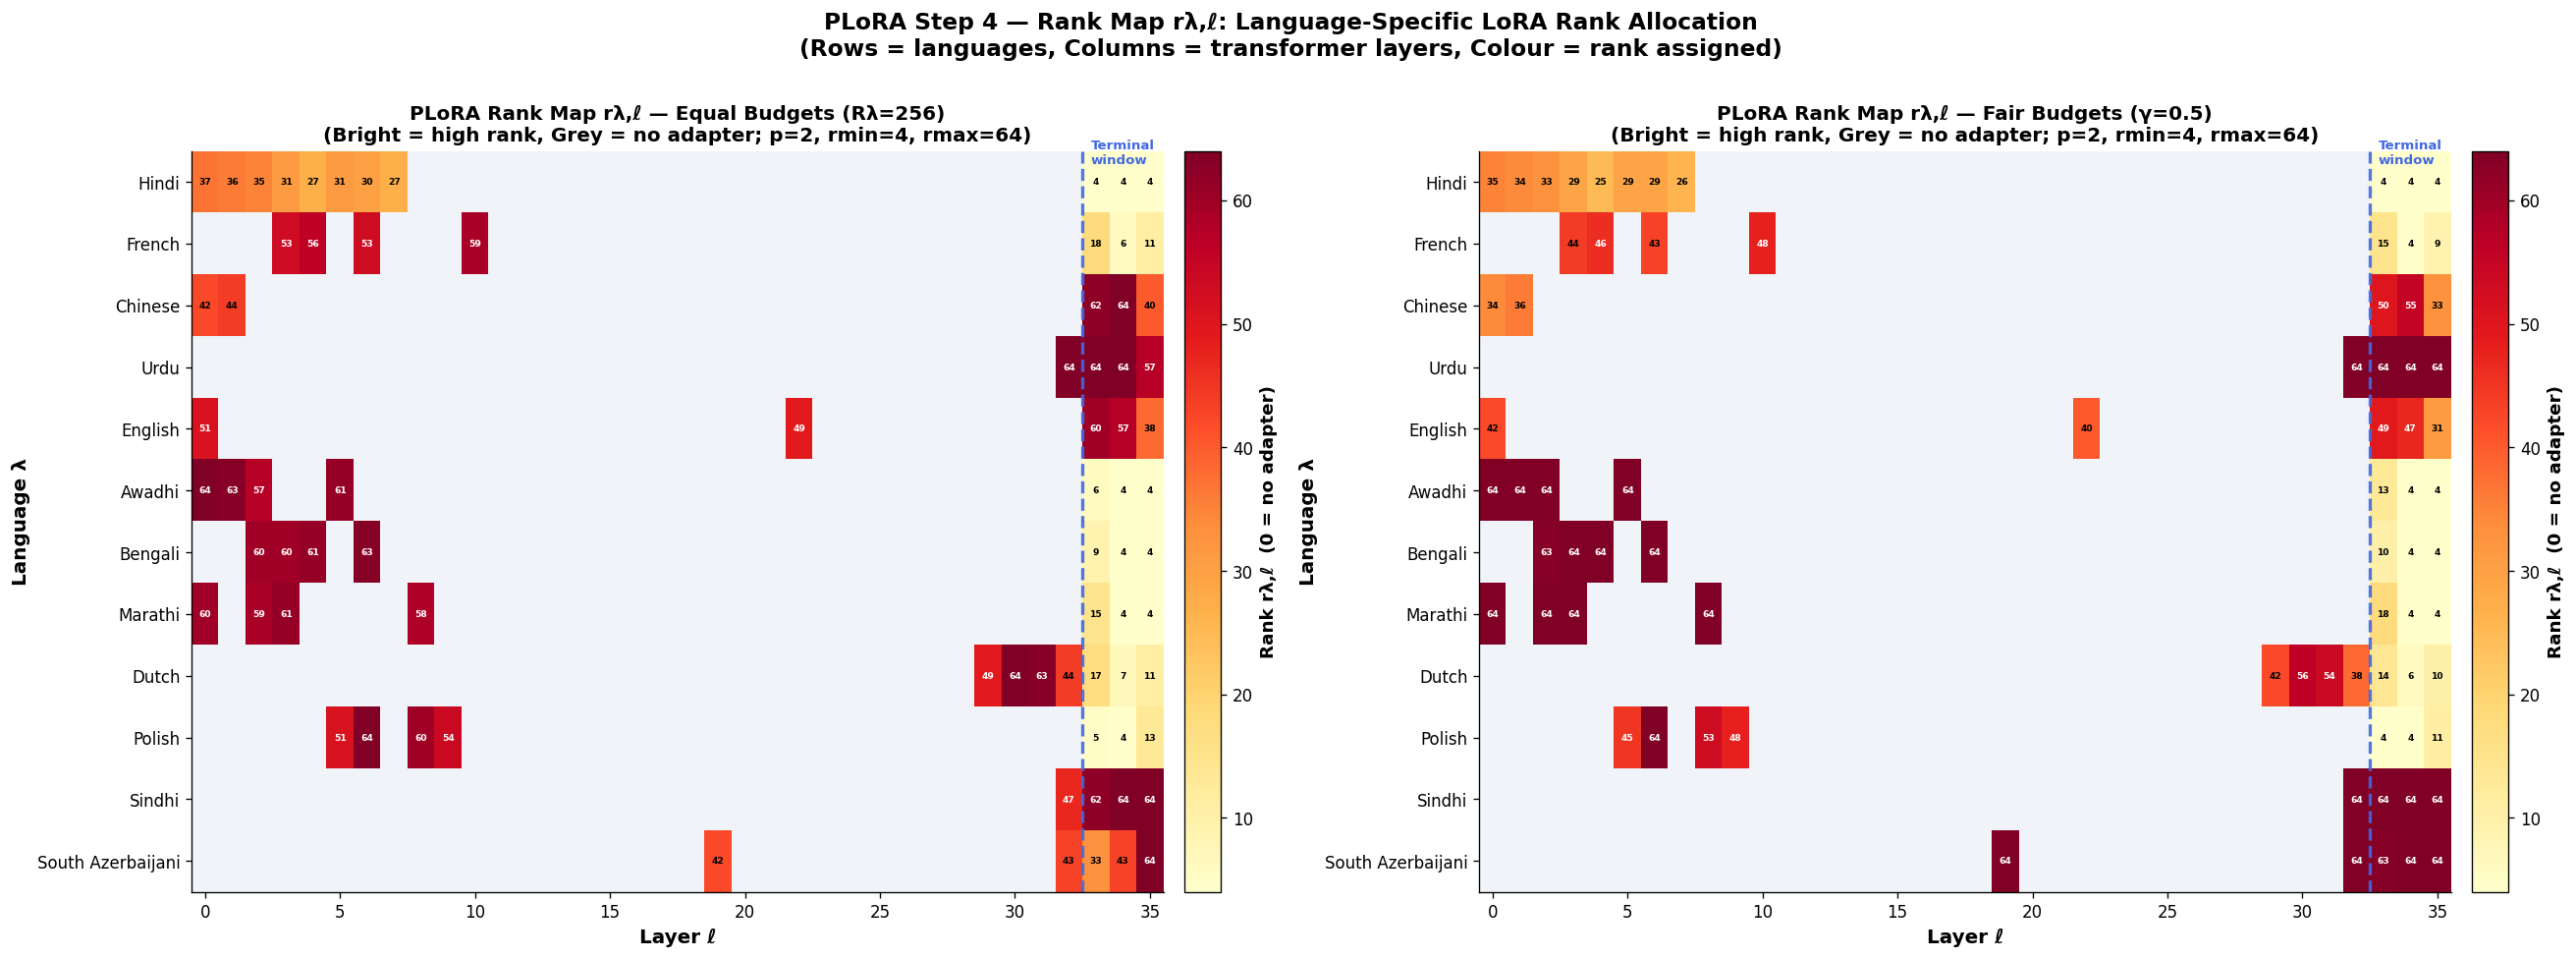

Saved: plora_step4_rank_map.png


In [22]:
# ────────────────────────────────────────────────────────────────────────────
# FIGURE 1 — Rank Map rλ,ℓ  (Primary required figure, PLoRA §1.8)
# ────────────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(22, 8))

for ax_idx, (ax, rank_mat, title_tag, budgets_used) in enumerate([
    (axes[0], rank_matrix_equal, f'Equal Budgets (Rλ={R_LAMBDA})', equal_budgets),
    (axes[1], rank_matrix_fair,  f'Fair Budgets (γ={GAMMA})',       fair_budgets),
]):
    # Mask zero entries (no adapter) with a distinct colour
    masked = np.ma.masked_equal(rank_mat, 0)

    cmap = plt.cm.YlOrRd.copy()
    cmap.set_bad(color='#F0F4F8')   # light grey for masked (no-adapter) cells

    im = ax.imshow(
        masked, aspect='auto', cmap=cmap,
        vmin=R_MIN, vmax=R_MAX, interpolation='nearest'
    )
    cbar = plt.colorbar(im, ax=ax, fraction=0.04, pad=0.02)
    cbar.set_label(f'Rank rλ,ℓ  (0 = no adapter)', fontsize=11, fontweight='bold')

    # Language tick labels
    ax.set_yticks(np.arange(len(lang_codes)))
    ax.set_yticklabels([LANGUAGES[lc] for lc in lang_codes], fontsize=10)
    ax.set_xlabel('Layer ℓ', fontsize=12, fontweight='bold')
    ax.set_ylabel('Language λ', fontsize=12, fontweight='bold')
    ax.set_title(
        f'PLoRA Rank Map rλ,ℓ — {title_tag}\n'
        f'(Bright = high rank, Grey = no adapter; p={P_EXP}, '
        f'rmin={R_MIN}, rmax={R_MAX})',
        fontsize=12, fontweight='bold'
    )

    # Annotate each cell with its rank value (only non-zero)
    for row in range(len(lang_codes)):
        for col in range(n_layers):
            v = rank_mat[row, col]
            if v > 0:
                ax.text(col, row, str(v), ha='center', va='center',
                        fontsize=5.5, color='black' if v < R_MAX * 0.7 else 'white',
                        fontweight='bold')

    # Draw terminal window boundary
    term_start = n_layers - TERMINAL_WINDOW - 0.5
    ax.axvline(term_start, color='royalblue', linewidth=2, linestyle='--', alpha=0.9)
    ax.text(term_start + 0.3, -0.7, 'Terminal\nwindow', color='royalblue',
            fontsize=8, fontweight='bold', va='top')

plt.suptitle(
    'PLoRA Step 4 — Rank Map rλ,ℓ: Language-Specific LoRA Rank Allocation\n'
    '(Rows = languages, Columns = transformer layers, Colour = rank assigned)',
    fontsize=14, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.savefig('plora_step4_rank_map.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: plora_step4_rank_map.png')

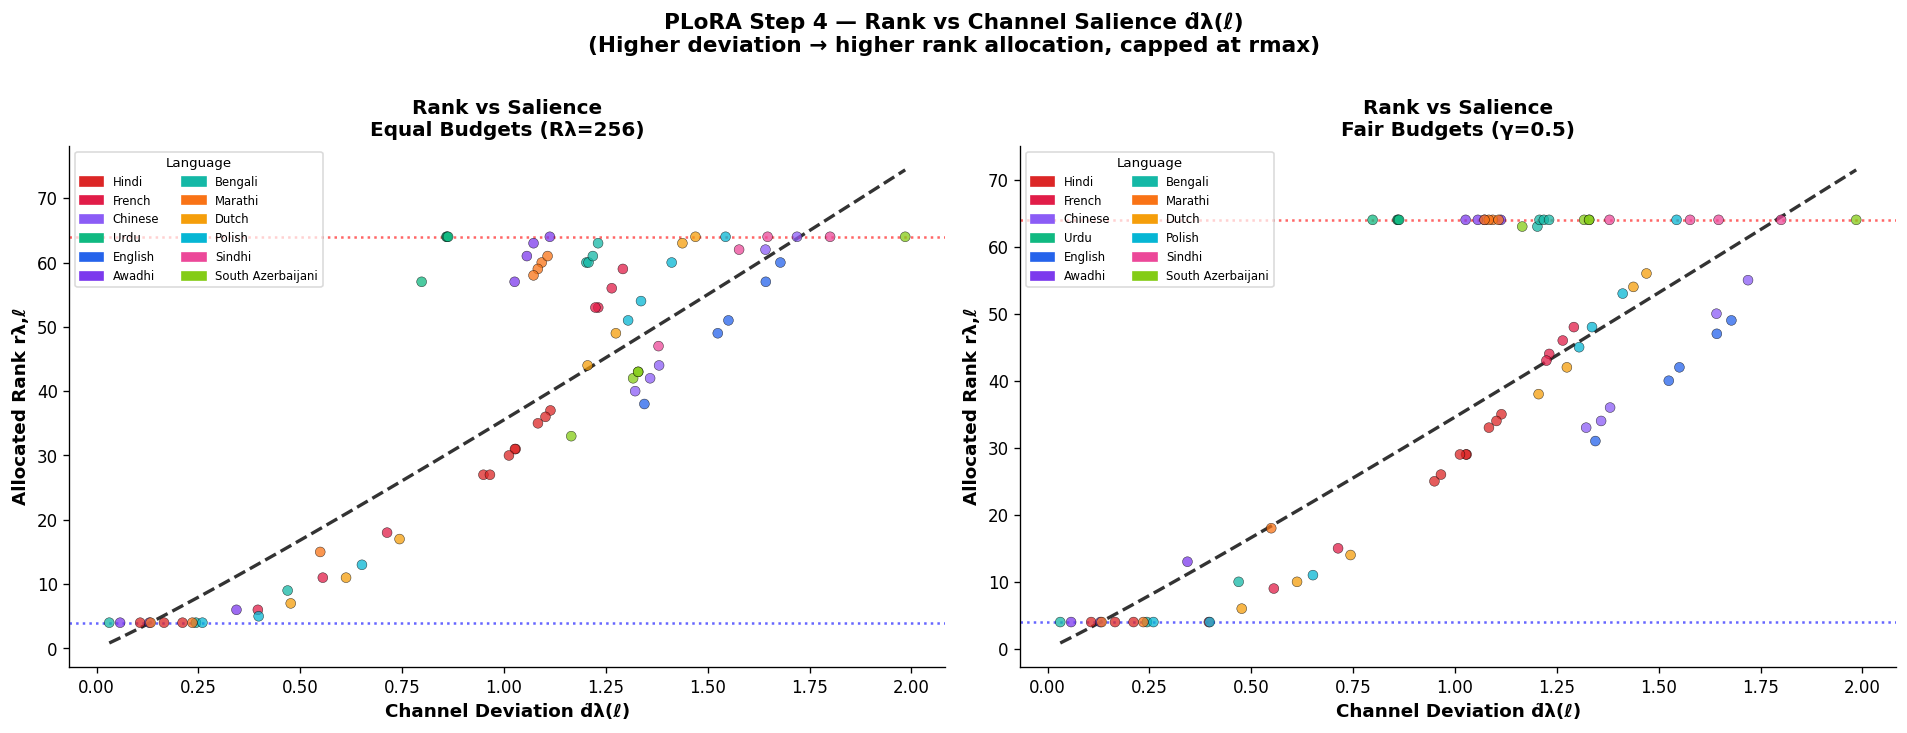

Saved: plora_step4_rank_vs_salience.png


In [23]:
# ────────────────────────────────────────────────────────────────────────────
# FIGURE 2 — Rank vs Channel Salience d̃λ(ℓ)
# Required by PLoRA §1.8: confirms capacity aligns with channel geometry
# ────────────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, rank_map_all, strategy in [
    (axes[0], all_ranks_equal, f'Equal Budgets (Rλ={R_LAMBDA})'),
    (axes[1], all_ranks_fair,  f'Fair Budgets (γ={GAMMA})'),
]:
    all_d   = []
    all_r   = []
    all_c   = []
    all_lbl = []

    for lc in lang_codes:
        for ell, r in rank_map_all[lc].items():
            all_d.append(d_tilde[lc][ell])
            all_r.append(r)
            all_c.append(LANGUAGE_COLORS.get(lc, '#888'))
            all_lbl.append(LANGUAGES[lc])

    ax.scatter(all_d, all_r, c=all_c, s=35, alpha=0.75,
               edgecolors='black', linewidth=0.3, zorder=3)

    # Fitted power-law trend  rλ,ℓ ≈ A · (d̃)^p  (log-log OLS)
    d_arr = np.array(all_d)
    r_arr = np.array(all_r, dtype=float)
    valid = (d_arr > 0) & (r_arr > 0)
    if valid.sum() > 3:
        slope, intercept, _, _, _ = stats.linregress(
            np.log(d_arr[valid] + 1e-8),
            np.log(r_arr[valid] + 1e-8)
        )
        xs = np.linspace(d_arr[valid].min(), d_arr[valid].max(), 200)
        ys = np.exp(intercept) * xs ** slope
        ax.plot(xs, ys, 'k--', linewidth=2, alpha=0.8,
                label=f'Trend: r ∝ d̃^{slope:.2f}')

    ax.axhline(R_MIN, color='blue',   linestyle=':',  linewidth=1.5, alpha=0.6, label=f'rmin={R_MIN}')
    ax.axhline(R_MAX, color='red',    linestyle=':',  linewidth=1.5, alpha=0.6, label=f'rmax={R_MAX}')
    ax.set_xlabel('Channel Deviation d̃λ(ℓ)', fontsize=11, fontweight='bold')
    ax.set_ylabel('Allocated Rank rλ,ℓ',      fontsize=11, fontweight='bold')
    ax.set_title(f'Rank vs Salience\n{strategy}', fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)

    # Legend for languages
    handles = [Patch(color=LANGUAGE_COLORS.get(lc, '#888'), label=LANGUAGES[lc])
               for lc in lang_codes]
    ax.legend(handles=handles, fontsize=7, ncol=2, loc='upper left',
              framealpha=0.7, title='Language', title_fontsize=8)

plt.suptitle(
    'PLoRA Step 4 — Rank vs Channel Salience d̃λ(ℓ)\n'
    '(Higher deviation → higher rank allocation, capped at rmax)',
    fontsize=13, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.savefig('plora_step4_rank_vs_salience.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: plora_step4_rank_vs_salience.png')

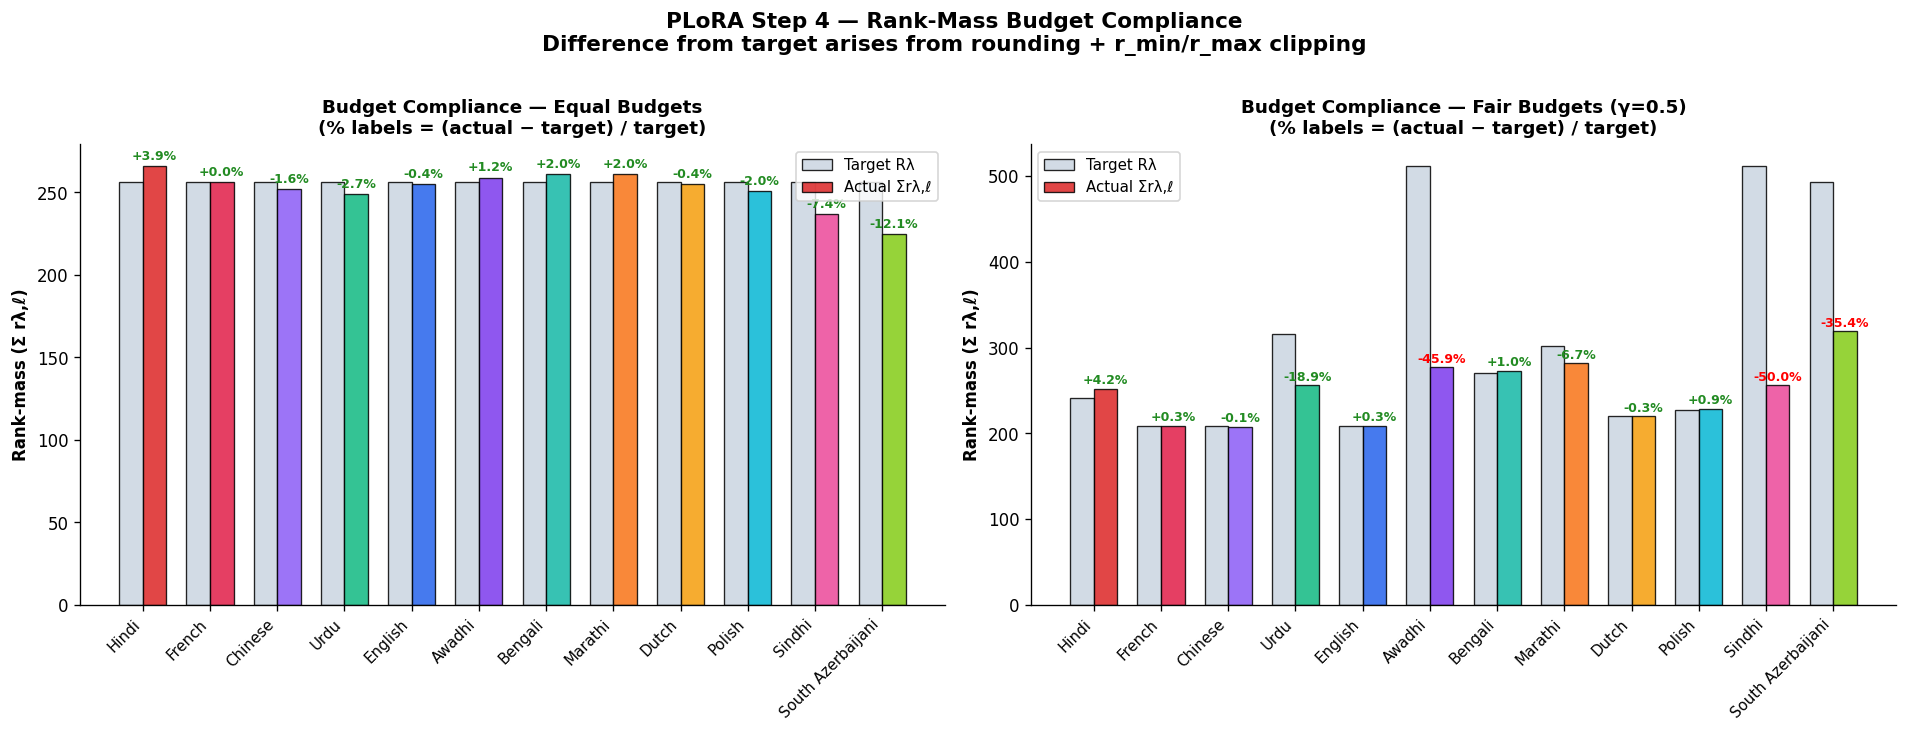

Saved: plora_step4_budget_compliance.png


In [24]:
# ────────────────────────────────────────────────────────────────────────────
# FIGURE 3 — Budget Compliance: Σrλ,ℓ vs Rλ
# ────────────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, rank_map_all, budgets_used, strategy in [
    (axes[0], all_ranks_equal, equal_budgets, f'Equal Budgets'),
    (axes[1], all_ranks_fair,  fair_budgets,  f'Fair Budgets (γ={GAMMA})'),
]:
    targets  = [budgets_used[lc] for lc in lang_codes]
    actuals  = [sum(rank_map_all[lc].values()) for lc in lang_codes]
    names    = [LANGUAGES[lc] for lc in lang_codes]
    clrs     = [LANGUAGE_COLORS.get(lc, '#888') for lc in lang_codes]
    errors   = [(a - t) / max(t, 1) * 100 for a, t in zip(actuals, targets)]

    x = np.arange(len(lang_codes))
    w = 0.35
    bars_t = ax.bar(x - w/2, targets, width=w, color='#CBD5E1', edgecolor='black',
                    linewidth=0.8, label='Target Rλ', alpha=0.85)
    bars_a = ax.bar(x + w/2, actuals, width=w, color=clrs, edgecolor='black',
                    linewidth=0.8, label='Actual Σrλ,ℓ', alpha=0.85)

    # Annotate error
    for i, (err, a) in enumerate(zip(errors, actuals)):
        color = 'red' if abs(err) > 20 else 'forestgreen'
        ax.text(i + w/2, a + 2, f'{err:+.1f}%', ha='center', va='bottom',
                fontsize=7.5, color=color, fontweight='bold')

    ax.set_xticks(x)
    ax.set_xticklabels(names, rotation=45, ha='right', fontsize=9)
    ax.set_ylabel('Rank-mass (Σ rλ,ℓ)', fontweight='bold')
    ax.set_title(f'Budget Compliance — {strategy}\n'
                 f'(% labels = (actual − target) / target)',
                 fontweight='bold', fontsize=11)
    ax.legend(fontsize=9)

plt.suptitle(
    'PLoRA Step 4 — Rank-Mass Budget Compliance\n'
    'Difference from target arises from rounding + r_min/r_max clipping',
    fontsize=13, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.savefig('plora_step4_budget_compliance.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: plora_step4_budget_compliance.png')

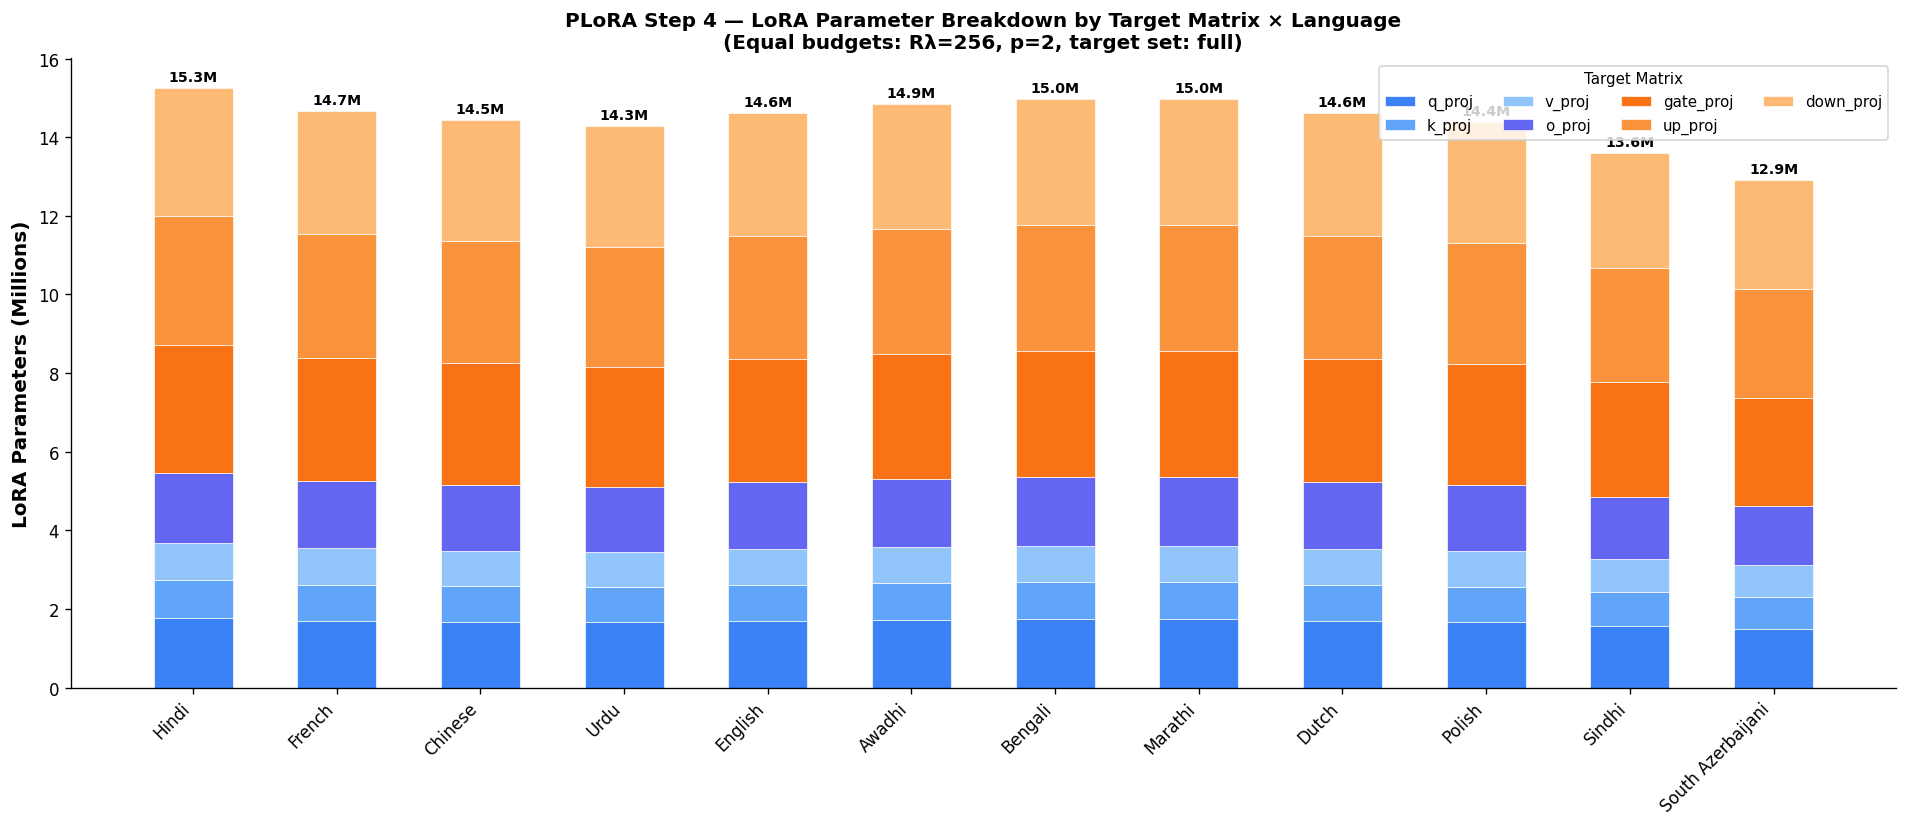

Saved: plora_step4_param_breakdown.png


In [25]:
# ────────────────────────────────────────────────────────────────────────────
# FIGURE 4 — Parameter Breakdown per Language × Target Set
# ────────────────────────────────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(16, 7))

target_names = ['q_proj', 'k_proj', 'v_proj', 'o_proj', 'gate_proj', 'up_proj', 'down_proj']
target_colors = {
    'q_proj'   : '#3B82F6', 'k_proj'   : '#60A5FA', 'v_proj'   : '#93C5FD',
    'o_proj'   : '#6366F1', 'gate_proj': '#F97316', 'up_proj'  : '#FB923C',
    'down_proj': '#FDBA74',
}

x     = np.arange(len(lang_codes))
width = 0.55
bottoms = np.zeros(len(lang_codes))

for tgt_name in target_names:
    if tgt_name not in LORA_TARGETS:
        continue
    din, dout = LORA_TARGETS[tgt_name]
    params_per_lang = []
    for lc in lang_codes:
        tot = sum(r * (din + dout) for r in all_ranks_equal[lc].values()) / 1e6
        params_per_lang.append(tot)
    ax.bar(x, params_per_lang, width=width, bottom=bottoms,
           color=target_colors.get(tgt_name, '#AAA'), edgecolor='white',
           linewidth=0.4, label=tgt_name)
    bottoms += np.array(params_per_lang)

# Annotate total
for i, (lc, tot) in enumerate(zip(lang_codes, bottoms)):
    ax.text(i, tot + 0.1, f'{tot:.1f}M', ha='center', va='bottom',
            fontsize=8.5, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels([LANGUAGES[lc] for lc in lang_codes], rotation=45, ha='right', fontsize=10)
ax.set_ylabel('LoRA Parameters (Millions)', fontsize=12, fontweight='bold')
ax.set_title(
    'PLoRA Step 4 — LoRA Parameter Breakdown by Target Matrix × Language\n'
    f'(Equal budgets: Rλ={R_LAMBDA}, p={P_EXP}, target set: {ACTIVE_TARGET_SET})',
    fontsize=12, fontweight='bold'
)
ax.legend(fontsize=9, ncol=4, loc='upper right', title='Target Matrix', title_fontsize=9)
plt.tight_layout()
plt.savefig('plora_step4_param_breakdown.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: plora_step4_param_breakdown.png')

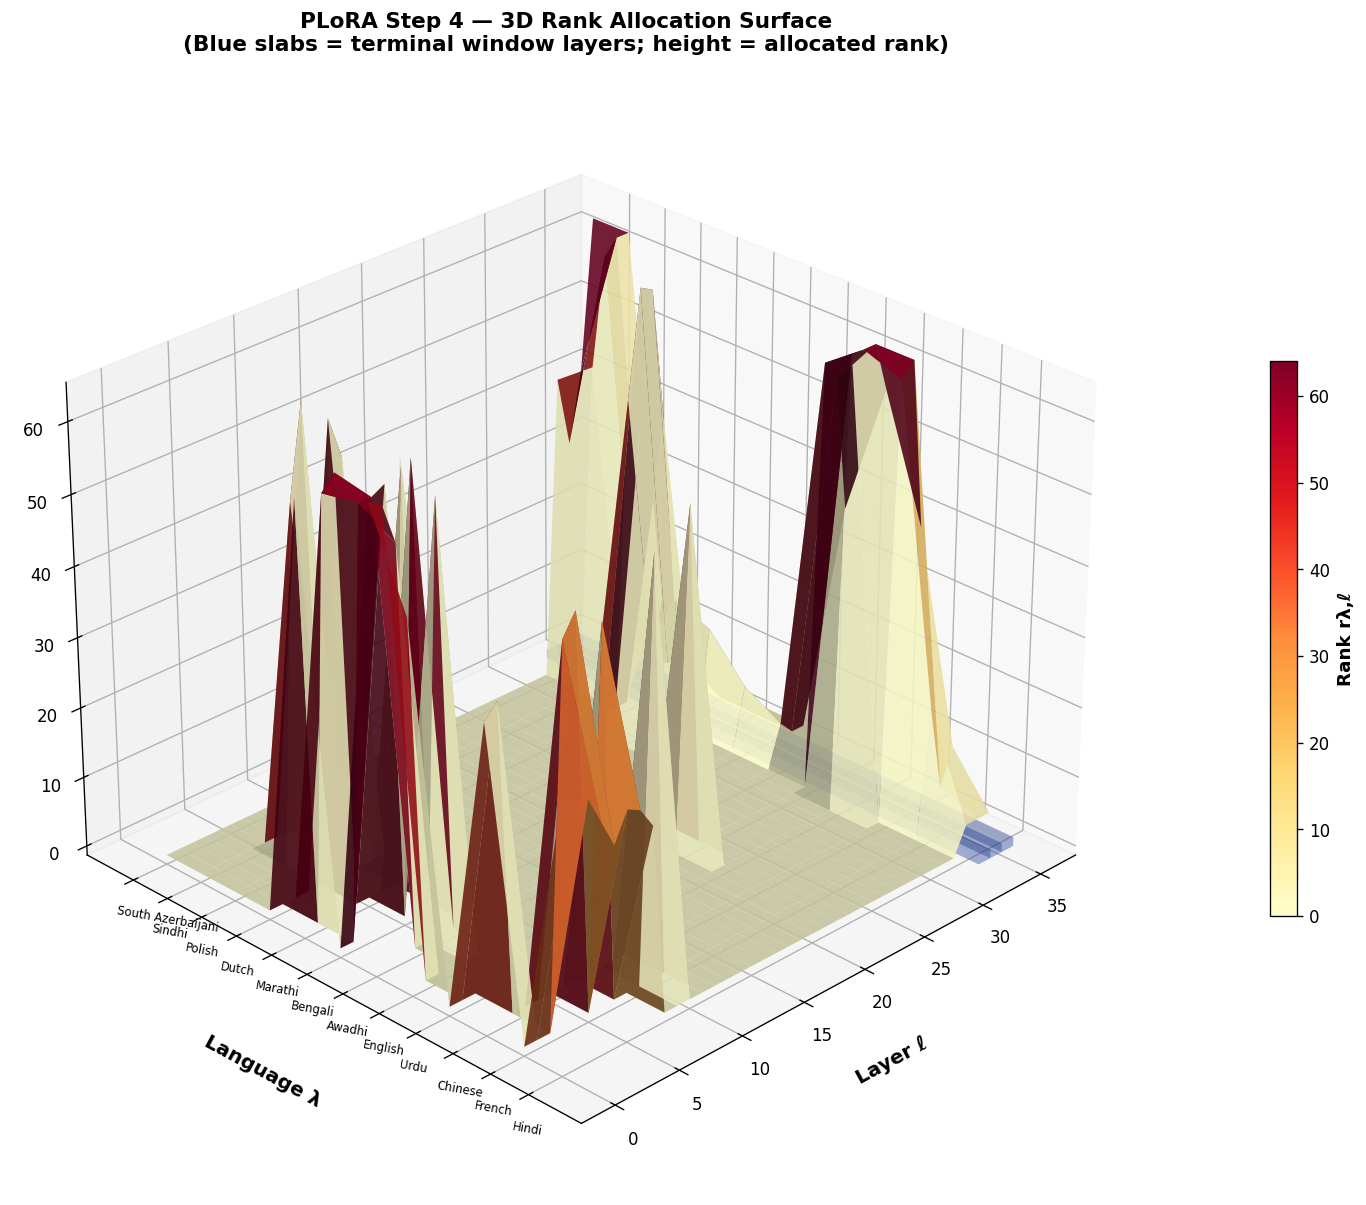

Saved: plora_step4_rank_surface_3d.png


In [27]:
# ────────────────────────────────────────────────────────────────────────────
# FIGURE 5 — 3D Rank Allocation Surface
# ────────────────────────────────────────────────────────────────────────────

fig = plt.figure(figsize=(20, 12))
ax  = fig.add_subplot(111, projection='3d')

X = np.arange(n_layers)          # layer axis
Y = np.arange(len(lang_codes))   # language axis
XX, YY = np.meshgrid(X, Y)
ZZ = rank_matrix_equal.astype(float)   # rank values

# Use face colours mapped to rank magnitude
norm  = Normalize(vmin=0, vmax=R_MAX)
cmap  = plt.cm.YlOrRd
fcolors = cmap(norm(ZZ))

surf = ax.plot_surface(
    XX, YY, ZZ,
    facecolors=fcolors,
    edgecolor='none',
    alpha=0.88, shade=True, antialiased=True
)

# Mark terminal-window layers
for t_layer in range(n_layers - TERMINAL_WINDOW, n_layers):
    z_col = ZZ[:, t_layer]
    ax.bar3d(
        x=t_layer - 0.5, y=-0.5, z=0,
        dx=1, dy=len(lang_codes),
        dz=R_MAX * 0.02,
        color='royalblue', alpha=0.25
    )

ax.set_xlabel('Layer ℓ',   fontsize=12, fontweight='bold', labelpad=15)
ax.set_ylabel('Language λ', fontsize=12, fontweight='bold', labelpad=20)
ax.set_zlabel('Rank rλ,ℓ', fontsize=12, fontweight='bold', labelpad=12)
ax.set_yticks(range(len(lang_codes)))
ax.set_yticklabels([LANGUAGES[lc] for lc in lang_codes], fontsize=7, rotation=-10, ha='left')
ax.set_title(
    'PLoRA Step 4 — 3D Rank Allocation Surface\n'
    '(Blue slabs = terminal window layers; height = allocated rank)',
    fontsize=13, fontweight='bold', pad=20
)
ax.view_init(elev=28, azim=225)

# Colorbar
m = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
m.set_array(ZZ)
cbar = fig.colorbar(m, ax=ax, shrink=0.5, pad=0.08)
cbar.set_label('Rank rλ,ℓ', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('plora_step4_rank_surface_3d.png', dpi=250, bbox_inches='tight')
plt.show()
print('Saved: plora_step4_rank_surface_3d.png')

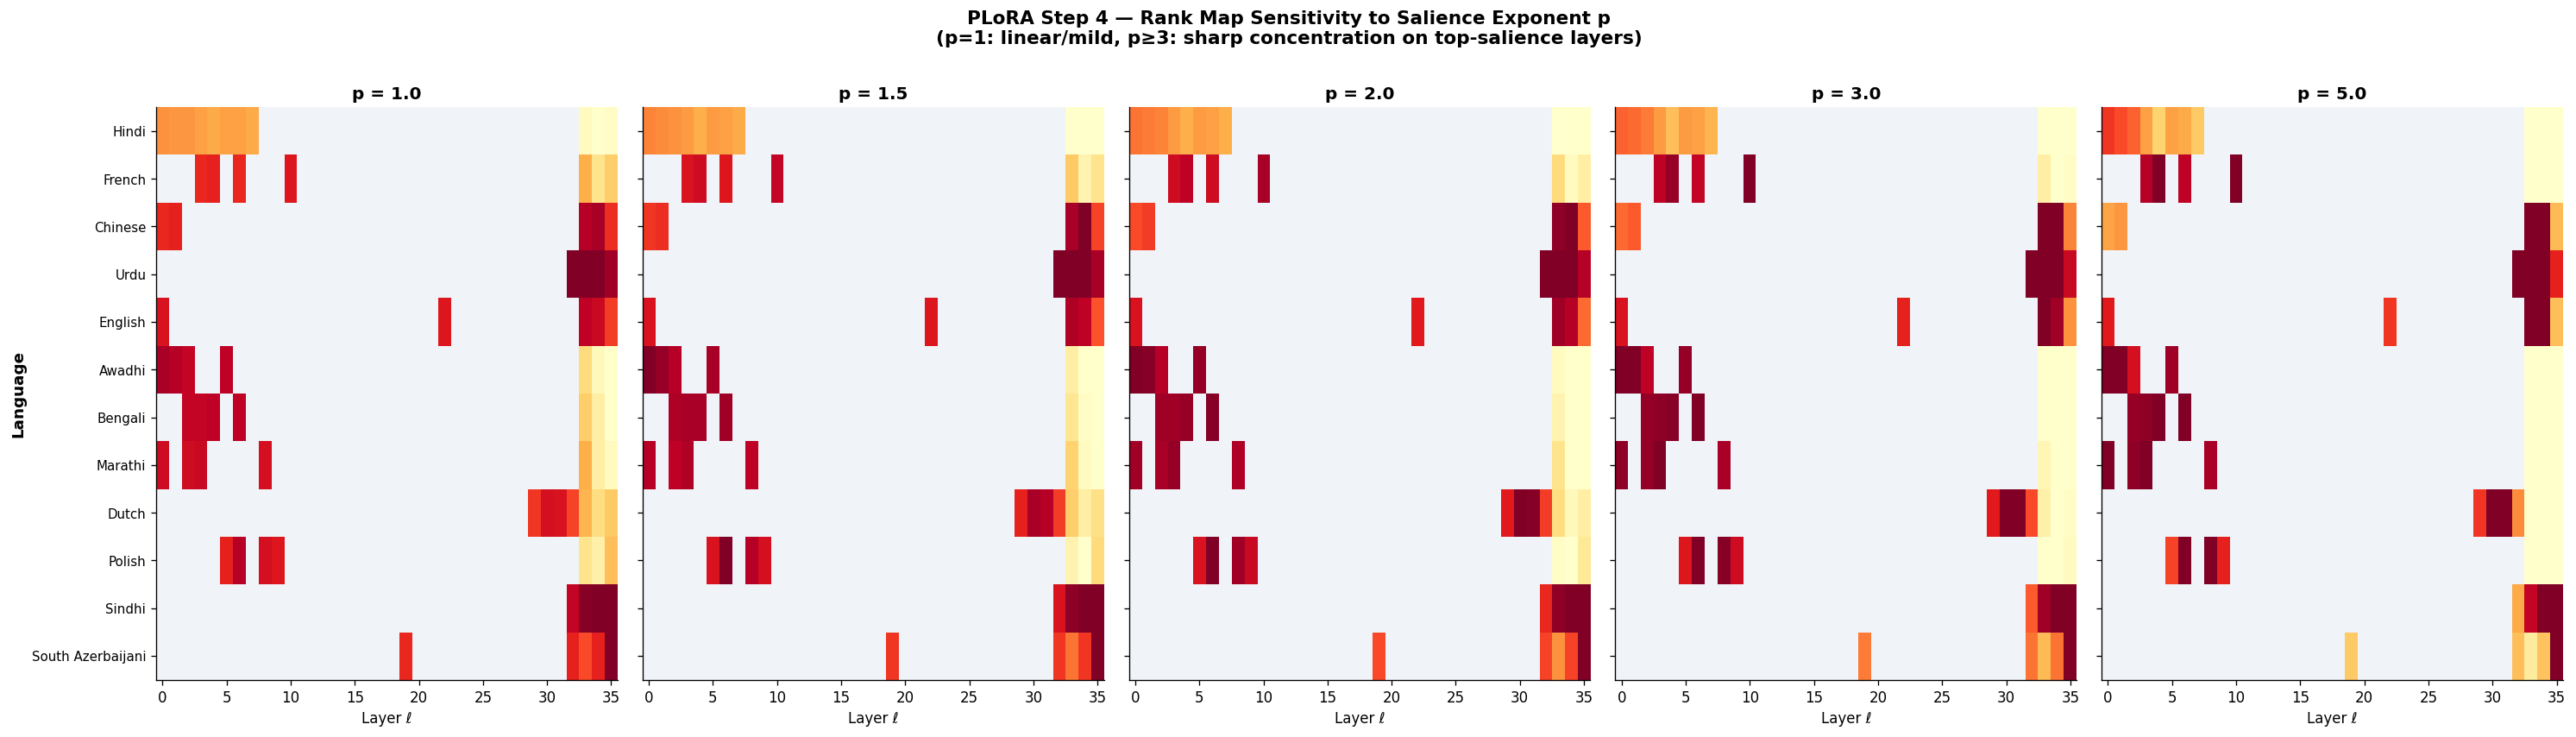

Saved: plora_step4_p_sweep.png


In [28]:
# ────────────────────────────────────────────────────────────────────────────
# FIGURE 6 — Rank Sensitivity: p-exponent Sweep
# Shows how the rank map changes as the salience exponent p varies.
# Helps practitioners choose p for their deployment scenario.
# ────────────────────────────────────────────────────────────────────────────

p_values = [1.0, 1.5, 2.0, 3.0, 5.0]
n_p = len(p_values)

fig, axes = plt.subplots(1, n_p, figsize=(5 * n_p, 7), sharey=True)

cmap_p = plt.cm.YlOrRd

for ax, p_val in zip(axes, p_values):
    # Compute allocation for this p
    ranks_p = {}
    for lc in lang_codes:
        ranks_p[lc] = allocate_ranks(
            d_tilde[lc], support_sets[lc], R_LAMBDA, R_MIN, R_MAX, p=p_val
        )
    mat_p = rank_map_matrix(ranks_p, lang_codes, n_layers)
    masked_p = np.ma.masked_equal(mat_p, 0)

    cmap_local = cmap_p.copy()
    cmap_local.set_bad(color='#F0F4F8')

    ax.imshow(masked_p, aspect='auto', cmap=cmap_local,
              vmin=R_MIN, vmax=R_MAX, interpolation='nearest')
    ax.set_title(f'p = {p_val}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Layer ℓ', fontsize=10)
    if ax == axes[0]:
        ax.set_yticks(np.arange(len(lang_codes)))
        ax.set_yticklabels([LANGUAGES[lc] for lc in lang_codes], fontsize=9)
        ax.set_ylabel('Language', fontsize=11, fontweight='bold')

plt.suptitle(
    'PLoRA Step 4 — Rank Map Sensitivity to Salience Exponent p\n'
    '(p=1: linear/mild, p≥3: sharp concentration on top-salience layers)',
    fontsize=13, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.savefig('plora_step4_p_sweep.png', dpi=250, bbox_inches='tight')
plt.show()
print('Saved: plora_step4_p_sweep.png')

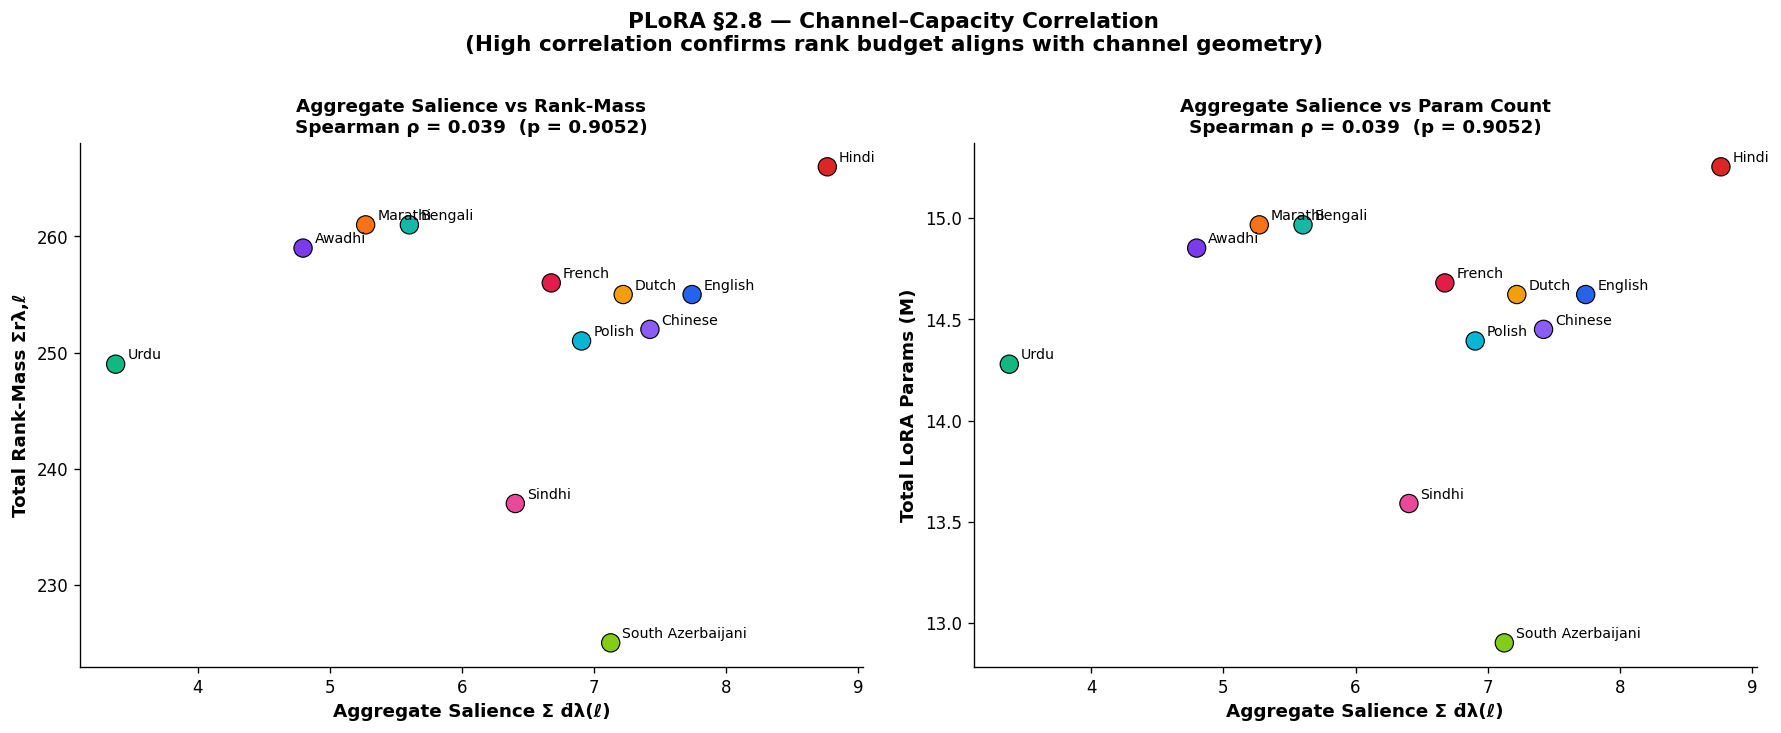

Saved: plora_step4_channel_gain_correlation.png


In [29]:
# ────────────────────────────────────────────────────────────────────────────
# FIGURE 7 — Channel–Gain Correlation Proxy
# PLoRA §2.8: correlate aggregate salience Σ_{ℓ∈Sλ} d̃λ(ℓ) with per-language
# parameter allocation (proxy for expected gain before training).
# ────────────────────────────────────────────────────────────────────────────

agg_salience = [
    sum(d_tilde[lc][ell] for ell in support_sets[lc])
    for lc in lang_codes
]
agg_params = [
    lora_param_cost_language(all_ranks_equal[lc]) / 1e6
    for lc in lang_codes
]
agg_rank_mass = [
    sum(all_ranks_equal[lc].values()) for lc in lang_codes
]

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for ax, yvals, ylabel, ytitle in [
    (axes[0], agg_rank_mass, 'Total Rank-Mass Σrλ,ℓ', 'Rank-Mass'),
    (axes[1], agg_params,    'Total LoRA Params (M)',   'Param Count'),
]:
    clrs = [LANGUAGE_COLORS.get(lc, '#888') for lc in lang_codes]
    ax.scatter(agg_salience, yvals, c=clrs, s=120, zorder=3,
               edgecolors='black', linewidth=0.7)

    for i, lc in enumerate(lang_codes):
        ax.annotate(
            LANGUAGES[lc], (agg_salience[i], yvals[i]),
            textcoords='offset points', xytext=(7, 3), fontsize=8.5
        )

    # Spearman correlation
    r_sp, p_sp = stats.spearmanr(agg_salience, yvals)
    ax.set_xlabel('Aggregate Salience Σ d̃λ(ℓ)', fontsize=11, fontweight='bold')
    ax.set_ylabel(ylabel, fontsize=11, fontweight='bold')
    ax.set_title(
        f'Aggregate Salience vs {ytitle}\nSpearman ρ = {r_sp:.3f}  (p = {p_sp:.4f})',
        fontsize=11, fontweight='bold'
    )

plt.suptitle(
    'PLoRA §2.8 — Channel–Capacity Correlation\n'
    '(High correlation confirms rank budget aligns with channel geometry)',
    fontsize=13, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.savefig('plora_step4_channel_gain_correlation.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: plora_step4_channel_gain_correlation.png')

## §4.6 — Soft Mixture Routing Extension

**PLoRA §1.7** specifies an optional soft routing mode for robustness to noisy or ambiguous language identification:
```
ΔWℓ(x) = Σλ p(λ|x) · ΔW(λ)ℓ
```
where `p(λ|x)` is the language posterior from a lightweight language ID predictor.

We implement the **merged effective rank** under soft routing, which determines the memory footprint at inference time when mixing adapters.

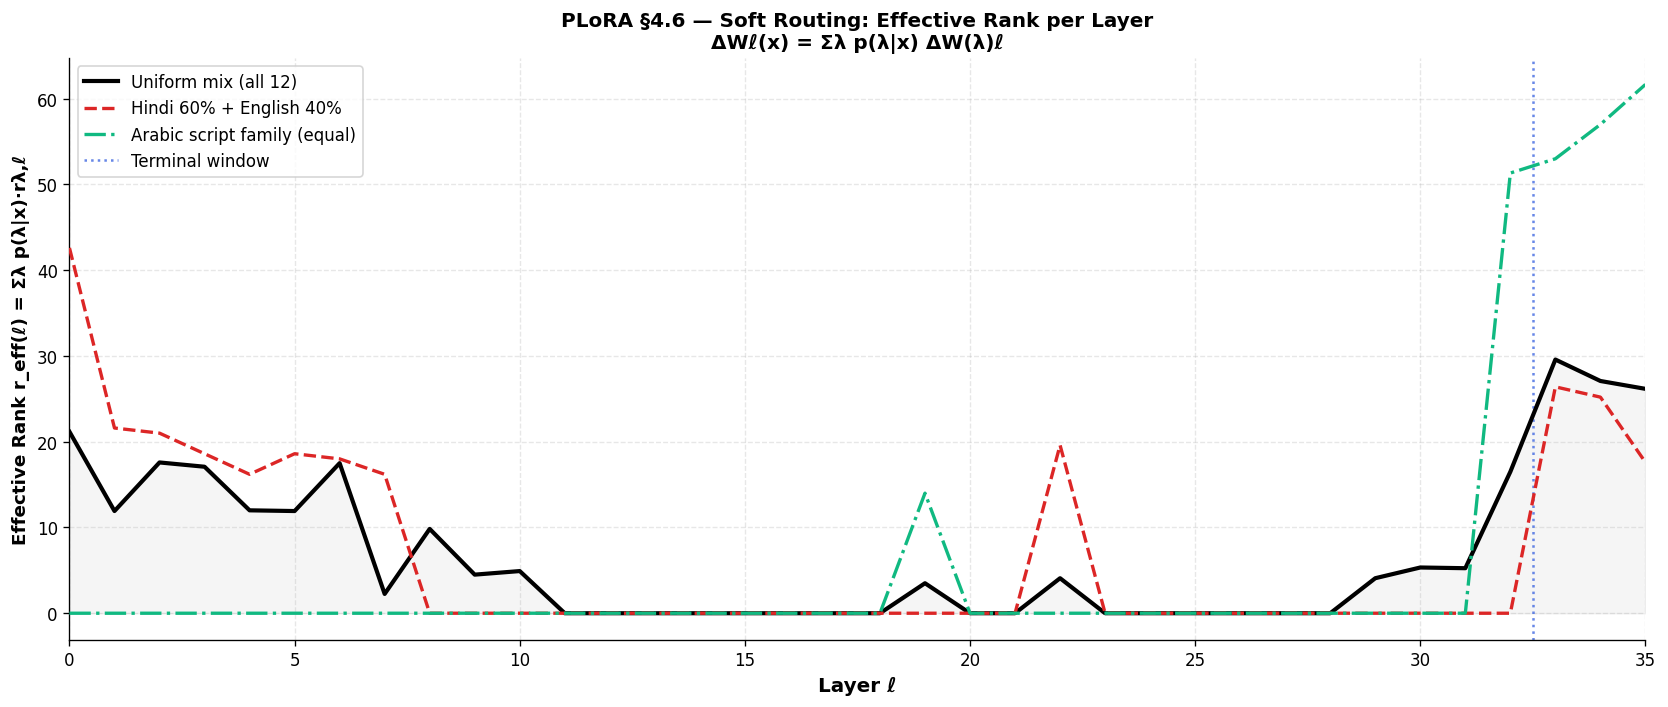

Saved: plora_step4_soft_routing.png

Effective rank statistics (uniform mix):
  Mean   : 7.01
  Max    : 29.58  (layer 33)
  Non-zero layers: 20


In [30]:
def soft_merge_effective_rank(
    all_ranks   : dict,
    lang_weights: dict,
    n_layers    : int,
) -> np.ndarray:
    """
    PLoRA §1.7 — Soft mixture routing: compute the weighted effective rank per layer.

    Given language mixing weights p(λ|x) summing to 1, the effective rank at
    layer ℓ under soft routing is:
        r_eff(ℓ) = Σλ p(λ|x) · rλ,ℓ

    This equals the expected LoRA rank under the language posterior — a useful
    proxy for the computational cost of soft routing at layer ℓ.

    Parameters
    ----------
    all_ranks    : {lang_code: {layer: rank}}
    lang_weights : {lang_code: weight}  — must sum to 1.0
    n_layers     : int

    Returns
    -------
    effective_ranks : np.ndarray of shape [n_layers]
    """
    weights = np.array(list(lang_weights.values()))
    weights = weights / (weights.sum() + 1e-12)   # renormalise

    eff = np.zeros(n_layers)
    for i, lc in enumerate(lang_weights):
        for ell, r in all_ranks.get(lc, {}).items():
            eff[ell] += weights[i] * r
    return eff


# ── Example: uniform mixing over all 12 languages ─────────────────────────
uniform_weights = {lc: 1.0 / len(lang_codes) for lc in lang_codes}
eff_uniform = soft_merge_effective_rank(all_ranks_equal, uniform_weights, n_layers)

# ── Example: 2-language code-switching (e.g., Hindi ↔ English) ─────────────
cs_weights_he = {lc: (0.6 if lc == 'hin_Deva' else (0.4 if lc == 'eng_Latn' else 0.0))
                 for lc in lang_codes}
eff_he = soft_merge_effective_rank(all_ranks_equal, cs_weights_he, n_layers)

# ── Example: Arabic script family mix ─────────────────────────────────────
arabic_langs = ['urd_Arab', 'snd_Arab', 'azb_Arab']
cs_weights_ar = {lc: (1.0/3 if lc in arabic_langs else 0.0) for lc in lang_codes}
eff_ar = soft_merge_effective_rank(all_ranks_equal, cs_weights_ar, n_layers)

# ── Plot ───────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 6))

layers = np.arange(n_layers)
ax.plot(layers, eff_uniform, 'k-',  linewidth=2.5, label='Uniform mix (all 12)', zorder=3)
ax.plot(layers, eff_he,      color='#DC2626', linewidth=2,
        linestyle='--', label='Hindi 60% + English 40%', zorder=3)
ax.plot(layers, eff_ar,      color='#10B981', linewidth=2,
        linestyle='-.', label='Arabic script family (equal)', zorder=3)

ax.fill_between(layers, 0, eff_uniform, alpha=0.08, color='gray')
ax.axvline(n_layers - TERMINAL_WINDOW - 0.5, color='royalblue',
           linestyle=':', linewidth=1.5, alpha=0.8, label='Terminal window')

ax.set_xlabel('Layer ℓ', fontsize=12, fontweight='bold')
ax.set_ylabel('Effective Rank r_eff(ℓ) = Σλ p(λ|x)·rλ,ℓ', fontsize=11, fontweight='bold')
ax.set_title(
    'PLoRA §4.6 — Soft Routing: Effective Rank per Layer\n'
    'ΔWℓ(x) = Σλ p(λ|x) ΔW(λ)ℓ',
    fontsize=12, fontweight='bold'
)
ax.legend(fontsize=10)
ax.set_xlim(0, n_layers - 1)
ax.grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig('plora_step4_soft_routing.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: plora_step4_soft_routing.png')

print(f'\nEffective rank statistics (uniform mix):')
print(f'  Mean   : {eff_uniform.mean():.2f}')
print(f'  Max    : {eff_uniform.max():.2f}  (layer {eff_uniform.argmax()})')
print(f'  Non-zero layers: {(eff_uniform > 0).sum()}')

## §4.7 — Comprehensive Summary Table

In [31]:
# ─── Build unified per-language summary ──────────────────────────────────────
rows_summary = []
for lc in lang_codes:
    rm_eq   = all_ranks_equal[lc]
    rm_fair = all_ranks_fair[lc]
    rs_eq   = list(rm_eq.values()) or [0]
    rs_fair = list(rm_fair.values()) or [0]

    margin, noise_bound, stable, _ = check_selection_margin(
        d_tilde[lc], alpha_std[lc], K_ALPHA
    )

    rows_summary.append({
        'Language'          : LANGUAGES[lc],
        'Code'              : lc,
        'Script'            : lc.split('_')[1] if '_' in lc else '?',
        '|Sλ|'              : len(rm_eq),
        'Equal: Σrank'      : sum(rs_eq),
        'Equal: rmin'       : min(rs_eq),
        'Equal: rmax'       : max(rs_eq),
        'Equal: r̄'          : round(np.mean(rs_eq), 2),
        'Equal: Params(M)'  : round(lora_param_cost_language(rm_eq) / 1e6, 3),
        'Fair Rλ'           : round(fair_budgets[lc], 1),
        'Fair: Σrank'       : sum(rs_fair),
        'Fair: r̄'           : round(np.mean(rs_fair), 2),
        'Fair: Params(M)'   : round(lora_param_cost_language(rm_fair) / 1e6, 3),
        'Dataset size'      : DATASET_SIZES.get(lc, '?'),
        'Selection stable'  : '✓' if stable else '⚠',
        'Margin'            : round(margin, 4),
        '2×Noise'           : round(noise_bound, 4),
        'Max d̃λ(ℓ)'         : round(max(d_tilde[lc]), 4),
        'Top layer'         : int(np.argmax(d_tilde[lc])),
    })

df_summary = pd.DataFrame(rows_summary)

# Print compact view
compact_cols = [
    'Language', '|Sλ|', 'Equal: r̄', 'Equal: Params(M)',
    'Fair Rλ', 'Fair: Params(M)', 'Selection stable', 'Top layer'
]
print('PLoRA Step 4 — Comprehensive Allocation Summary')
print(df_summary[compact_cols].to_string(index=False))

# Totals
print(f'\n  Total LoRA params (equal, all languages): '
      f'{df_summary["Equal: Params(M)"].sum():.2f}M')
print(f'  Total LoRA params (fair,  all languages): '
      f'{df_summary["Fair: Params(M)"].sum():.2f}M')
print(f'  Base model (frozen): ~{MODEL_ARCH.get("vocab_size",0)*d/1e9:.2f}B (embeddings) + rest frozen')

PLoRA Step 4 — Comprehensive Allocation Summary
         Language  |Sλ|  Equal: r̄  Equal: Params(M)  Fair Rλ  Fair: Params(M) Selection stable  Top layer
            Hindi    11      24.18            15.254    241.7           14.451                ⚠          0
           French     7      36.57            14.680    208.3           11.985                ⚠         10
          Chinese     5      50.40            14.451    208.3           11.928                ⚠         34
             Urdu     4      62.25            14.279    315.6           14.680                ⚠         34
          English     5      51.00            14.623    208.3           11.985                ⚠         33
           Awadhi     7      37.00            14.852    512.0           15.884                ⚠          0
          Bengali     7      37.29            14.967    270.3           15.655                ⚠          6
          Marathi     7      37.29            14.967    302.2           16.171                ⚠ 

## §4.8 — Persist Rank Allocation for Step 5 (Training)

Step 5 (language-routed training) will load `plora_step4_rank_budgets.json` and instantiate LoRA adapters exactly as specified here. The schema is:

```json
{
  "metadata": { ... config ... },
  "equal_budget": {
    "eng_Latn": {"2": 8, "7": 16, ...},
    ...
  },
  "fair_budget": { ... }
}
```

In [32]:
# ─── Serialise rank maps (convert int keys to str for JSON) ──────────────────
def serialise_rank_map(all_ranks):
    return {lc: {str(ell): r for ell, r in rm.items()}
            for lc, rm in all_ranks.items()}

# ─── Build full output payload ────────────────────────────────────────────────
output = {
    'metadata': {
        'model_id'        : MODEL_ID,
        'n_layers'        : n_layers,
        'n_languages'     : len(lang_codes),
        'languages'       : {lc: LANGUAGES[lc] for lc in lang_codes},

        # Rank budget hyperparameters
        'R_lambda_equal'  : R_LAMBDA,
        'R_min'           : R_MIN,
        'R_max'           : R_MAX,
        'p_exp'           : P_EXP,

        # Fairness
        'gamma'           : GAMMA,
        'R_fair_min'      : R_FAIR_MIN,
        'R_fair_max'      : R_FAIR_MAX,
        'fair_budgets'    : {lc: round(v, 2) for lc, v in fair_budgets.items()},

        # Support set provenance
        'K_alpha'         : K_ALPHA,
        'terminal_window' : TERMINAL_WINDOW,
        'step3_source'    : step3_source,

        # Architecture
        'model_arch'      : MODEL_ARCH,
        'lora_target_set' : ACTIVE_TARGET_SET,
        'lora_targets'    : {k: list(v) for k, v in LORA_TARGETS.items()},

        # Parameter counts
        'total_params_equal_M' : round(total_params_all / 1e6, 3),
        'total_params_fair_M'  : round(
            sum(lora_param_cost_language(all_ranks_fair[lc]) for lc in lang_codes) / 1e6, 3
        ),
    },

    # Per-language support sets (from Step 3 or computed fallback)
    'support_sets': {lc: support_sets[lc] for lc in lang_codes},

    # Core deliverable: rank allocations
    'equal_budget': serialise_rank_map(all_ranks_equal),
    'fair_budget' : serialise_rank_map(all_ranks_fair),

    # Effective-rank under soft routing (uniform mix)
    'soft_routing': {
        'uniform_mix_effective_rank': eff_uniform.tolist(),
        'hindi_english_mix'         : eff_he.tolist(),
        'arabic_family_mix'         : eff_ar.tolist(),
    },
}

# ─── Write JSON ───────────────────────────────────────────────────────────────
JSON_OUT = 'plora_step4_rank_budgets.json'
with open(JSON_OUT, 'w', encoding='utf-8') as f:
    json.dump(output, f, indent=2, ensure_ascii=False)
print(f'✓ Saved: {JSON_OUT}  ({Path(JSON_OUT).stat().st_size / 1024:.1f} KB)')

✓ Saved: plora_step4_rank_budgets.json  (7.5 KB)


In [33]:
# ─── Write tabular CSV (one row per language × layer) ────────────────────────
rows_csv = []
for lc in lang_codes:
    for ell in range(n_layers):
        r_eq   = all_ranks_equal[lc].get(ell, 0)
        r_fair = all_ranks_fair[lc].get(ell, 0)
        in_S   = ell in support_sets[lc]
        rows_csv.append({
            'lang_code'        : lc,
            'lang_name'        : LANGUAGES[lc],
            'layer'            : ell,
            'in_support_set'   : int(in_S),
            'd_tilde'          : round(d_tilde[lc][ell], 6),
            'alpha_mean'       : round(alpha_mean[lc][ell], 6),
            'rank_equal'       : r_eq,
            'rank_fair'        : r_fair,
            'params_equal'     : lora_param_cost_per_layer(r_eq)  if r_eq  > 0 else 0,
            'params_fair'      : lora_param_cost_per_layer(r_fair) if r_fair > 0 else 0,
            'terminal_window'  : int(ell >= n_layers - TERMINAL_WINDOW),
            'weight_eq'        : round((max(d_tilde[lc][ell], 1e-8) ** P_EXP) if in_S else 0, 6),
        })

df_out = pd.DataFrame(rows_csv)
CSV_OUT = 'plora_step4_rank_budgets.csv'
df_out.to_csv(CSV_OUT, index=False)
print(f'✓ Saved: {CSV_OUT}  ({len(df_out)} rows)')

# ─── Summary stats CSV ───────────────────────────────────────────────────────
SUMMARY_OUT = 'plora_step4_param_summary.csv'
df_summary.to_csv(SUMMARY_OUT, index=False)
print(f'✓ Saved: {SUMMARY_OUT}  ({len(df_summary)} rows)')

# Preview
print(f'\nSample rows from {CSV_OUT}:')
print(df_out[df_out['in_support_set'] == 1].head(10).to_string(index=False))

✓ Saved: plora_step4_rank_budgets.csv  (432 rows)
✓ Saved: plora_step4_param_summary.csv  (12 rows)

Sample rows from plora_step4_rank_budgets.csv:
lang_code lang_name  layer  in_support_set  d_tilde  alpha_mean  rank_equal  rank_fair  params_equal  params_fair  terminal_window  weight_eq
 hin_Deva     Hindi      0               1 1.113987    0.958128          37         35       2121728      2007040                0   1.240968
 hin_Deva     Hindi      1               1 1.101692    1.156675          36         34       2064384      1949696                0   1.213726
 hin_Deva     Hindi      2               1 1.083265    1.231450          35         33       2007040      1892352                0   1.173462
 hin_Deva     Hindi      3               1 1.028470    1.367173          31         29       1777664      1662976                0   1.057751
 hin_Deva     Hindi      4               1 0.949487    1.498428          27         25       1548288      1433600                0   0.901526


In [34]:
# ─── Final sanity check: reload JSON and verify integrity ────────────────────
with open(JSON_OUT) as f:
    reloaded = json.load(f)

print('JSON integrity check:')
print(f'  Languages in file : {len(reloaded["equal_budget"])}')
print(f'  Metadata keys     : {list(reloaded["metadata"].keys())}')

# Spot-check one language
spot_lc  = lang_codes[0]
spot_rm  = reloaded['equal_budget'][spot_lc]
spot_tot = sum(int(v) for v in spot_rm.values())
print(f'  Spot-check [{LANGUAGES[spot_lc]}]: {len(spot_rm)} layers, Σrank={spot_tot}')

print(f'\n✓ All outputs saved and verified.')
print(f'\nOutputs for Step 5 (Training):')
print(f'  {JSON_OUT}           ← primary input for adapter instantiation')
print(f'  {CSV_OUT}     ← tabular layer × language allocation')
print(f'  {SUMMARY_OUT}  ← language-level summary stats')

JSON integrity check:
  Languages in file : 12
  Metadata keys     : ['model_id', 'n_layers', 'n_languages', 'languages', 'R_lambda_equal', 'R_min', 'R_max', 'p_exp', 'gamma', 'R_fair_min', 'R_fair_max', 'fair_budgets', 'K_alpha', 'terminal_window', 'step3_source', 'model_arch', 'lora_target_set', 'lora_targets', 'total_params_equal_M', 'total_params_fair_M']
  Spot-check [Hindi]: 11 layers, Σrank=266

✓ All outputs saved and verified.

Outputs for Step 5 (Training):
  plora_step4_rank_budgets.json           ← primary input for adapter instantiation
  plora_step4_rank_budgets.csv     ← tabular layer × language allocation
  plora_step4_param_summary.csv  ← language-level summary stats


## Step 4 — Complete ✓

### Summary of deliverables

| File | Description |
|---|---|
| `plora_step4_rank_budgets.json` | Full allocation: metadata + support sets + rank maps (equal & fair) |
| `plora_step4_rank_budgets.csv` | Tabular version (lang × layer × rank) |
| `plora_step4_param_summary.csv` | Per-language summary statistics |
| `plora_step4_rank_map.png` | **Primary figure**: rank map rλ,ℓ heatmap (equal & fair) |
| `plora_step4_rank_vs_salience.png` | Rank vs d̃λ(ℓ) — capacity alignment verification |
| `plora_step4_budget_compliance.png` | Budget compliance: Σrλ,ℓ vs Rλ |
| `plora_step4_param_breakdown.png` | LoRA params by target matrix × language |
| `plora_step4_rank_surface_3d.png` | 3D rank surface (language × layer × rank) |
| `plora_step4_p_sweep.png` | Sensitivity to salience exponent p |
| `plora_step4_channel_gain_correlation.png` | Aggregate salience vs total params |
| `plora_step4_fairness_budgets.png` | Fair budget γ sweep & dataset-size curve |
| `plora_step4_soft_routing.png` | Effective rank under soft mixture routing |

### For Step 5 needs

```python
# In Step 5 (training), load the allocation:
import json
with open('plora_step4_rank_budgets.json') as f:
    alloc = json.load(f)

# Choose strategy
rank_maps = alloc['equal_budget']   # or 'fair_budget'

# Instantiate per-language adapters
for lang_code, layer_ranks in rank_maps.items():
    for str_layer, rank in layer_ranks.items():
        layer = int(str_layer)
        # attach LoRA(rank=rank) to model.layers[layer] for language=lang_code
```

### Key design decisions

| Hyperparameter | Value | Why |
|---|---|---|
| `R_LAMBDA` | 256 | ~13 layers × avg rank 20 |
| `R_MIN` | 4 | Prevents zero adaptation at any selected layer |
| `R_MAX` | 64 | Memory bound; matches common PEFT practices |
| `P_EXP` | 2 | Quadratic → moderate sharpening without collapse |
| `GAMMA` | 0.5 | Moderate minority boost (square-root inverse) |
| `K_ALPHA` | 10 | ~28% of layers; leaves room for terminal window |
| `TERMINAL_WINDOW` | 3 | Last 3 layers always included (SPINAL evidence) |